<a href="https://colab.research.google.com/github/hechoii/do_an_tot_nghiep/blob/main/FINAL_RESULT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PAPER_FINAL_GAT_MAPPO_BENCHMARK — COMMUNICATION + SAFETY SHIELD V1 READY

This notebook is configured for the full final run. It adds:
- communication-aware user observations,
- safety-aware UAV-neighbor observations,
- a service-coverage term in the paper reward,
- Greedy-Demand-Safe heuristic baseline,
- k-nearest UAV graph attention for GAT-MAPPO.

After the smoke test passes, switch to the final preset/tag or use the FINAL_READY companion notebook.


**Shield V1 update:** actions are executed through a minimum-separation safety projection layer. The benchmark manager saves and evaluates the best safe checkpoint instead of blindly evaluating the last PPO checkpoint.


In [ ]:
# ============================================================
# Cell 1 — Imports, Global Configuration, and Reproducibility
# Notebook: PAPER_FINAL_GAT_MAPPO_BENCHMARK
# ============================================================

import os
import json
import math
import time
import random
import warnings
import re
import hashlib
from dataclasses import dataclass, asdict, replace
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Keep CPU fallback smoke tests responsive in constrained notebook runtimes.
# This does not limit CUDA kernels when a GPU is available.
try:
    torch.set_num_threads(min(4, max(1, os.cpu_count() or 1)))
    torch.set_num_interop_threads(1)
except Exception:
    pass
print(f"Using device: {DEVICE}")

# ============================================================
# Execution profile
# ============================================================
NOTEBOOK_TITLE = "PAPER_FINAL_GAT_MAPPO_BENCHMARK_COMMSAFETY_SHIELD_B128_V1"
QUICK_TEST = False
RESUME_FROM_CACHE = True
STRICT_RESUME_CHECK = True
SAVE_CHECKPOINTS = True
SAVE_EVERY_EPISODES = 10
KEEP_EPISODE_SNAPSHOTS = False

# IMPORTANT:
# Every materially different reward/config/environment revision MUST use a new tag.
CHECKPOINT_RUN_TAG = "paper_final_stagingmobility_commsafety_shield_b128_v1"

# Final paper run preset.
# This notebook is locked to the manuscript setting:
#   4 seeds, 1500 training episodes, 10 evaluation episodes.
# For smoke/pilot tests, copy this notebook and change CHECKPOINT_RUN_TAG.
EXPERIMENT_PRESET = "paper_final_stagingmobility_commsafety_shield_b128_final"

# ------------------------------------------------------------
# Google Drive persistence for Colab
# ------------------------------------------------------------
# Checkpoints are stored at exactly:
#   /content/drive/MyDrive/6g_uav/checkpoints/
# If the path does not exist, it is created automatically.
IN_COLAB = os.path.exists("/content")
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE_ROOT = "/content/drive/MyDrive/6g_uav"
    except Exception as exc:
        print(f"[WARN] Google Drive mount failed: {exc}")
        print("[WARN] Falling back to /content/6g_uav. Checkpoints will not survive Colab reset.")
        DRIVE_ROOT = "/content/6g_uav"
else:
    DRIVE_ROOT = os.path.abspath("./6g_uav")

OUTPUT_DIR = os.path.join(DRIVE_ROOT, "outputs")
CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

SAFE_RUN_TAG = re.sub(r"[^A-Za-z0-9_.-]+", "_", CHECKPOINT_RUN_TAG)
RESULTS_JSON = os.path.join(OUTPUT_DIR, f"main_benchmark_{SAFE_RUN_TAG}.json")

ALGORITHMS_MAIN = ["Static-Fixed", "Random", "Greedy-Demand-Safe", "IPPO", "MAPPO", "GAT-MAPPO"]
GAT_ABLATIONS = [
    "Static-Fixed",
    "Random",
    "IPPO",
    "GAT-MAPPO Full",
    "GAT-MAPPO w/o Weighted Adjacency",
    "GAT-MAPPO w/o Graph Critic",
    "GAT-MAPPO w/o Adaptive Power",
]

SCALES = {
    "paper_main":     {"num_uav": 6,  "num_users": 60},
    "low_density":    {"num_uav": 6,  "num_users": 60},
    "medium_density": {"num_uav": 10, "num_users": 100},
    "high_density":   {"num_uav": 15, "num_users": 150},
}


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


def to_jsonable(obj: Any) -> Any:
    if isinstance(obj, dict):
        return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [to_jsonable(x) for x in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.float32, np.float64)):
        return float(obj)
    if isinstance(obj, (np.int32, np.int64)):
        return int(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    return obj


def save_json_atomic(data: Dict[str, Any], path: str) -> None:
    """Atomic JSON writer with fsync + os.sync for Colab crash/disconnect resilience."""
    tmp = path + ".tmp"
    with open(tmp, "w", encoding="utf-8") as f:
        json.dump(to_jsonable(data), f, indent=2)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, path)
    try:
        os.sync()
    except Exception:
        pass


def load_json(path: str) -> Dict[str, Any]:
    if not os.path.exists(path):
        return {}
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def ci95_t(arr: np.ndarray) -> float:
    arr = np.asarray(arr, dtype=np.float64)
    n = len(arr)
    if n <= 1:
        return 0.0
    se = np.std(arr, ddof=1) / math.sqrt(n)
    tcrit = float(stats.t.ppf(0.975, df=n - 1))
    return float(tcrit * se)


@dataclass
class Config:
    # Environment scale consistent with the manuscript system model.
    num_uav: int = 6
    num_users: int = 60
    area_size: float = 1500.0
    uav_altitude: float = 100.0
    init_margin_frac: float = 0.10
    # UAV initial placement policy for the final benchmark.
    # "fixed_staging" means every algorithm starts from the same
    # deterministic, safety-feasible, deliberately suboptimal staging layout
    # near the lower edge of the area. Users/hotspots/demands remain randomized
    # by the environment seed and episode sequence.
    uav_init_mode: str = "fixed_staging"
    init_min_separation_factor: float = 1.25
    init_position_max_tries: int = 10000
    staging_y_frac: float = 0.10
    staging_x_low_frac: float = 0.17
    staging_x_high_frac: float = 0.83

    # User spatial distribution: clustered hotspots + uniform background in a
    # task region away from the UAV staging line. This makes the initial score
    # intentionally non-optimal and forces learning policies to reposition UAVs.
    hotspot_count: int = 3
    hotspot_user_frac: float = 0.70
    hotspot_sigma_m: float = 90.0
    task_x_low_frac: float = 0.20
    task_x_high_frac: float = 0.80
    task_y_low_frac: float = 0.55
    task_y_high_frac: float = 0.90
    background_users_in_task_region: bool = True
    dt: float = 1.0
    episode_len: int = 100

    # Communication model aligned with the paper.
    # Links beyond comm_range are unavailable in _compute_rates().
    # The reported coverage metric is service/rate-based:
    #     G(t) = (1/K) sum_k 1{R_k(t) >= coverage_rate_mbps}.
    # coverage_radius is retained only as a geometric reference equal to comm_range;
    # it is not used to define ep_coverage in the final paper benchmark.
    fc_ghz: float = 2.4
    total_bw_hz: float = 20e6
    n_subchannels: int = 6
    noise_figure_db: float = 9.0
    temperature_k: float = 290.0
    max_tx_power_w: float = 2.0
    power_logit_scale: float = 5.0
    aclr_interference: float = 0.15
    comm_range: float = 400.0
    coverage_radius: float = 400.0
    collision_dist: float = 40.0
    qos_rate_mbps: float = 2.0
    coverage_rate_mbps: float = 0.1
    rician_k: float = 8.0
    shadow_los_sigma_db: float = 4.0
    shadow_nlos_sigma_db: float = 7.8

    # Mobility
    uav_vmax: float = 20.0
    # Heterogeneous user mobility: most users walk, while a minority move
    # faster as vehicle-like users. The legacy user_vmax is retained as a
    # compatibility field but is not the final mobility sampler.
    user_vmax: float = 2.0
    pedestrian_frac: float = 0.70
    pedestrian_speed_min: float = 0.5
    pedestrian_speed_max: float = 1.5
    vehicle_speed_min: float = 4.0
    vehicle_speed_max: float = 10.0
    pedestrian_turn_std_rad: float = 0.35
    vehicle_turn_std_rad: float = 0.08
    # Communication- and safety-aware local observations.
    # Every learning baseline receives the same local observation. GAT-MAPPO
    # differs only in how it processes the UAV-UAV relation graph.
    # Nearest-UAV feature per neighbor:
    #   dx/L, dy/L, d/R_comm, (d-d_min)/d_min, collision_risk.
    # Nearest-user feature per user:
    #   dx/L, dy/L, d/R_comm, demand/qos, last_rate/qos,
    #   qos_deficit/qos, covered_flag.
    # Local communication summary:
    #   local_mean_rate/qos, local_qos_ratio, local_coverage_ratio,
    #   local_mean_deficit/qos, local_load_ratio.
    max_uav_neighbors: int = 3
    max_user_neighbors: int = 3
    local_comm_feature_dim: int = 5
    safety_warn_factor: float = 3.0
    separation_risk_weight: float = 5.0

    # Safety shield / projection layer. The policy still outputs a continuous
    # velocity action, but the simulator projects the next UAV positions back to
    # a minimum-separation feasible set before applying motion. This turns
    # collision handling from a pure post-hoc reward penalty into an executable
    # safety layer, while keeping the same observation/action interface.
    enable_safety_projection: bool = True
    safety_projection_min_dist_factor: float = 1.10
    safety_projection_iterations: int = 8
    safety_projection_apply_in_eval: bool = True

    # Best-checkpoint and collapse handling. PPO-family policies can degrade
    # after finding a good coordination policy; final evaluation therefore uses
    # the best safe checkpoint, not necessarily the last checkpoint.
    best_checkpoint_min_episode: int = 50
    enable_early_stop_on_collapse: bool = True
    collapse_check_after_episode: int = 300
    collapse_collision_threshold: float = 40.0
    collapse_reward_threshold: float = -500.0

    gat_k_nearest: int = 3

    # Per-user traffic-demand state used by communication-aware observations
    # and the Greedy-Demand-Safe heuristic. The paper QoS threshold remains
    # qos_rate_mbps; demand is an observed traffic-load feature, not an oracle.
    enable_user_demand: bool = True
    user_demand_min_mbps: float = 0.5
    user_demand_max_mbps: float = 2.0
    user_demand_update_std: float = 0.05

    # Direct service-coverage reward coefficient for the paper objective.
    coverage_reward_weight: float = 2.0

    # Battery and energy
    enable_battery: bool = True
    battery_init: float = 100.0
    battery_scale: float = 4000.0
    depleted_team_penalty: float = 0.20

    # Paper reward switch. If False, the legacy hybrid shaping below is used.
    use_paper_reward: bool = True
    lyapunov_kappa: float = 0.5

    # Legacy hybrid reward weights retained only for ablation/debug experiments.
    w_tput: float = 0.15
    w_qos: float = 0.25
    w_cov: float = 0.25
    w_fair: float = 0.15
    w_load: float = 0.10
    w_coll: float = 0.45
    w_near: float = 0.30
    w_energy: float = 0.05
    w_motion_start: float = 0.00
    w_motion_end: float = 0.02
    motion_anneal_start_ep: int = 1
    motion_anneal_end_ep: int = 500
    team_reward_weight: float = 0.45
    local_reward_weight: float = 0.55
    near_collision_factor: float = 3.0
    energy_ref: float = 300.0
    tput_ref_mbps: float = 650.0

    # PPO/MAPPO/GAT-MAPPO protocol from the paper.
    gamma: float = 0.99          # Paper notation: beta.
    gae_lambda: float = 0.95
    ppo_clip: float = 0.20
    ppo_epochs: int = 5
    ppo_minibatch_size: int = 128
    entropy_coef: float = 0.020
    value_coef: float = 0.50
    max_grad_norm: float = 10.0
    actor_lr: float = 1e-4
    critic_lr: float = 3e-4
    hidden_dim: int = 128
    gat_heads: int = 4
    gat_layers: int = 2

    # MADDPG retained in code only; not used in the final paper benchmark.
    maddpg_lr_actor: float = 5e-5
    maddpg_lr_critic: float = 2e-4
    maddpg_tau: float = 0.005
    maddpg_gamma: float = 0.99
    replay_capacity: int = 50000
    replay_batch: int = 128
    exploration_noise: float = 0.05

    # Training protocol
    train_episodes: int = 1500
    baseline_episodes: int = 50
    eval_episodes: int = 10

    # Observation/action dimensions
    action_dim: int = 3
    use_agent_id: bool = True

    @property
    def noise_power_w(self) -> float:
        """Thermal-noise model: N0 = k_B T B F_NF."""
        k_b = 1.380649e-23
        nf_linear = 10.0 ** (self.noise_figure_db / 10.0)
        return float(k_b * self.temperature_k * self.total_bw_hz * nf_linear)

    @property
    def obs_dim(self) -> int:
        # own 7 + optional one-hot agent id + nearest UAV safety features
        # + communication-aware nearest-user features + local communication summary.
        user_feature_dim = 7
        base = (
            7
            + self.max_uav_neighbors * 5
            + self.max_user_neighbors * user_feature_dim
            + self.local_comm_feature_dim
        )
        return base + (self.num_uav if self.use_agent_id else 0)

    @property
    def global_dim(self) -> int:
        return self.num_uav * self.obs_dim


def config_fingerprint(cfg: Config) -> str:
    payload = json.dumps(to_jsonable(asdict(cfg)), sort_keys=True)
    return hashlib.sha1(payload.encode("utf-8")).hexdigest()[:12]


PRESETS = {
    "smoke": {
        "run_seeds": [0],
        "run_scales": {"paper_main": SCALES["paper_main"]},
        "train_episodes": 5,
        "baseline_episodes": 2,
        "eval_episodes": 2,
    },
    "pilot": {
        "run_seeds": [0],
        "run_scales": {"paper_main": SCALES["paper_main"]},
        "train_episodes": 100,
        "baseline_episodes": 10,
        "eval_episodes": 5,
    },
    "paper_final": {
        "run_seeds": [0, 1, 2, 3, 4],
        "run_scales": {"paper_main": SCALES["paper_main"]},
        "train_episodes": 1500,
        "baseline_episodes": 50,
        "eval_episodes": 10,
    },
    # Fixed-initial-layout final preset. The environment starts every
    # algorithm from the same deterministic UAV layout, while users/hotspots
    # and demand states remain randomized by seed/episode.
    "paper_final_stagingmobility": {
        "run_seeds": [0, 1, 2, 3, 4],
        "run_scales": {"paper_main": SCALES["paper_main"]},
        "train_episodes": 1500,
        "baseline_episodes": 50,
        "eval_episodes": 10,
    },
    # Staging-layout final preset. UAVs start from the same deliberately
    # suboptimal staging line, while task users/hotspots and heterogeneous
    # pedestrian/vehicle mobility remain randomized by seed/episode.
    "paper_final_stagingmobility": {
        "run_seeds": [0, 1, 2, 3, 4],
        "run_scales": {"paper_main": SCALES["paper_main"]},
        "train_episodes": 1500,
        "baseline_episodes": 50,
        "eval_episodes": 10,
    },
    # Communication+safety-v2 smoke preset. Use this first to verify shapes, reward terms,
    # Greedy-Demand-Safe, and all PPO/GAT updates before the expensive final run.
    "paper_final_stagingmobility_commsafety_smoke": {
        "run_seeds": [0],
        "run_scales": {"paper_main": SCALES["paper_main"]},
        "train_episodes": 5,
        "baseline_episodes": 1,
        "eval_episodes": 1,
    },
    # Legacy communication+safety-v2 preset retained for compatibility.
    "paper_final_stagingmobility_commsafety_final": {
        "run_seeds": [0, 1, 2, 3],
        "run_scales": {"paper_main": SCALES["paper_main"]},
        "train_episodes": 1500,
        "baseline_episodes": 50,
        "eval_episodes": 10,
    },

    # Communication+safety-shield-b128 final preset. Corrected final run with safety projection
    # and larger PPO minibatches for faster optimizer updates.
    "paper_final_stagingmobility_commsafety_shield_b128_final": {
        "run_seeds": [0, 1, 2, 3],
        "run_scales": {"paper_main": SCALES["paper_main"]},
        "train_episodes": 1500,
        "baseline_episodes": 50,
        "eval_episodes": 10,
    },

}


ALGORITHMS_TO_RUN = ALGORITHMS_MAIN
preset = PRESETS[EXPERIMENT_PRESET]
RUN_SEEDS = list(preset["run_seeds"])
SEEDS = list(RUN_SEEDS)
RUN_SCALES = dict(preset["run_scales"])

BASE_CFG = replace(
    Config(),
    num_uav=6,
    num_users=60,
    area_size=1500.0,
    train_episodes=int(preset["train_episodes"]),
    baseline_episodes=int(preset["baseline_episodes"]),
    eval_episodes=int(preset["eval_episodes"]),
)

print("Notebook:", NOTEBOOK_TITLE)
print("Preset:", EXPERIMENT_PRESET)
print("Run tag:", CHECKPOINT_RUN_TAG)
print("Results JSON:", RESULTS_JSON)
print("Run seeds:", RUN_SEEDS)
print("Run scales:", RUN_SCALES)
print("Algorithms:", ALGORITHMS_TO_RUN)
print("Base cfg hash:", config_fingerprint(BASE_CFG))
print(BASE_CFG)


Using device: cuda
Mounted at /content/drive
Notebook: PAPER_FINAL_GAT_MAPPO_BENCHMARK_COMMSAFETY_SHIELD_B128_V1
Preset: paper_final_stagingmobility_commsafety_shield_b128_final
Run tag: paper_final_stagingmobility_commsafety_shield_b128_v1
Results JSON: /content/drive/MyDrive/6g_uav/outputs/main_benchmark_paper_final_stagingmobility_commsafety_shield_b128_v1.json
Run seeds: [0, 1, 2, 3]
Run scales: {'paper_main': {'num_uav': 6, 'num_users': 60}}
Algorithms: ['Static-Fixed', 'Random', 'Greedy-Demand-Safe', 'IPPO', 'MAPPO', 'GAT-MAPPO']
Base cfg hash: 392a3f6039f9
Config(num_uav=6, num_users=60, area_size=1500.0, uav_altitude=100.0, init_margin_frac=0.1, uav_init_mode='fixed_staging', init_min_separation_factor=1.25, init_position_max_tries=10000, staging_y_frac=0.1, staging_x_low_frac=0.17, staging_x_high_frac=0.83, hotspot_count=3, hotspot_user_frac=0.7, hotspot_sigma_m=90.0, task_x_low_frac=0.2, task_x_high_frac=0.8, task_y_low_frac=0.55, task_y_high_frac=0.9, background_users_in_tas

## Cell 1B — Paper final benchmark override

Cell này ghi đè cấu hình sau Cell 1 để chạy đúng cấu hình paper final.

In [ ]:
# ============================================================
# Cell 1B — PAPER FINAL BENCHMARK OVERRIDE
# Purpose:
#   Synchronize the executable experiment with the manuscript:
#   M=6, K=60, L=1500 m, H=100 m, fc=2.4 GHz,
#   thermal noise, sigmoid power control, paper shared reward,
#   Lyapunov safety queue, and final PPO/GAT settings.
# ============================================================

NOTEBOOK_TITLE = "PAPER_FINAL_GAT_MAPPO_BENCHMARK_COMMSAFETY_SHIELD_B128_V1"
EXPERIMENT_PRESET = "paper_final_stagingmobility_commsafety_shield_b128_final"
CHECKPOINT_RUN_TAG = "paper_final_stagingmobility_commsafety_shield_b128_v1"

# Resume is enabled only for the same run_tag + config hash.
# Older tuned/checkpoint runs are ignored by STRICT_RESUME_CHECK.
RESUME_FROM_CACHE = True
STRICT_RESUME_CHECK = True
SAVE_CHECKPOINTS = True
SAVE_EVERY_EPISODES = 10
KEEP_EPISODE_SNAPSHOTS = False

RUN_SEEDS = [0, 1, 2, 3]
SEEDS = list(RUN_SEEDS)

RUN_SCALES = {
    "paper_main": {
        "num_uav": 6,
        "num_users": 60,
    }
}

ALGORITHMS_TO_RUN = [
    "Static-Fixed",
    "Random",
    "Greedy-Demand-Safe",
    "IPPO",
    "MAPPO",
    "GAT-MAPPO",
]

BASE_CFG = replace(
    Config(),
    num_uav=6,
    num_users=60,
    area_size=1500.0,
    uav_init_mode="fixed_staging",
    init_min_separation_factor=1.25,
    init_position_max_tries=10000,
    staging_y_frac=0.10,
    staging_x_low_frac=0.17,
    staging_x_high_frac=0.83,
    task_x_low_frac=0.20,
    task_x_high_frac=0.80,
    task_y_low_frac=0.55,
    task_y_high_frac=0.90,
    background_users_in_task_region=True,

    train_episodes=1500,
    baseline_episodes=50,
    eval_episodes=10,

    uav_altitude=100.0,
    uav_vmax=20.0,
    user_vmax=2.0,  # retained for compatibility; final sampler uses fields below
    pedestrian_frac=0.70,
    pedestrian_speed_min=0.5,
    pedestrian_speed_max=1.5,
    vehicle_speed_min=4.0,
    vehicle_speed_max=10.0,
    pedestrian_turn_std_rad=0.35,
    vehicle_turn_std_rad=0.08,

    fc_ghz=2.4,
    total_bw_hz=20e6,
    noise_figure_db=9.0,
    temperature_k=290.0,
    max_tx_power_w=2.0,
    power_logit_scale=5.0,
    comm_range=400.0,
    coverage_radius=400.0,      # geometric link reference; final ep_coverage is rate-based.
    coverage_rate_mbps=0.1,     # service coverage threshold R_cov.
    collision_dist=40.0,
    qos_rate_mbps=2.0,

    hidden_dim=128,
    gat_heads=4,
    gat_layers=2,

    ppo_epochs=5,
    ppo_minibatch_size=128,
    ppo_clip=0.20,
    gamma=0.99,
    gae_lambda=0.95,
    max_grad_norm=10.0,

    max_uav_neighbors=3,
    max_user_neighbors=3,
    local_comm_feature_dim=5,
    safety_warn_factor=3.0,
    separation_risk_weight=5.0,
    enable_safety_projection=True,
    safety_projection_min_dist_factor=1.10,
    safety_projection_iterations=8,
    safety_projection_apply_in_eval=True,
    best_checkpoint_min_episode=50,
    enable_early_stop_on_collapse=True,
    collapse_check_after_episode=300,
    collapse_collision_threshold=40.0,
    collapse_reward_threshold=-500.0,
    gat_k_nearest=3,
    near_collision_factor=3.0,
    lyapunov_kappa=0.5,
    enable_user_demand=True,
    user_demand_min_mbps=0.5,
    user_demand_max_mbps=2.0,
    user_demand_update_std=0.05,
    coverage_reward_weight=2.0,
    use_paper_reward=True,
)

SAFE_RUN_TAG = re.sub(r"[^A-Za-z0-9_.-]+", "_", CHECKPOINT_RUN_TAG)
RESULTS_JSON = os.path.join(OUTPUT_DIR, f"main_benchmark_{SAFE_RUN_TAG}.json")

print("=" * 80)
print("[PAPER FINAL BENCHMARK OVERRIDE ACTIVE]")
print("Notebook:", NOTEBOOK_TITLE)
print("Run tag:", CHECKPOINT_RUN_TAG)
print("Resume:", RESUME_FROM_CACHE)
print("Results JSON:", RESULTS_JSON)
print("Run seeds:", RUN_SEEDS)
print("Run scales:", RUN_SCALES)
print("Algorithms:", ALGORITHMS_TO_RUN)
print("Train episodes:", BASE_CFG.train_episodes)
print("Baseline episodes:", BASE_CFG.baseline_episodes)
print("Eval episodes:", BASE_CFG.eval_episodes)
print("Checkpoint every episodes:", SAVE_EVERY_EPISODES)
print("Final learning runs:", len([a for a in ALGORITHMS_TO_RUN if a not in ["Static-Fixed", "Random", "Greedy-Demand-Safe"]]) * len(RUN_SEEDS))
print("paper reward:", BASE_CFG.use_paper_reward)
print("noise_power_w:", BASE_CFG.noise_power_w)
print("hidden/heads/layers:", BASE_CFG.hidden_dim, BASE_CFG.gat_heads, BASE_CFG.gat_layers)
print("ppo minibatch size:", BASE_CFG.ppo_minibatch_size)
print("safety neighbors / warn / sep weight / gat k:", BASE_CFG.max_uav_neighbors, BASE_CFG.safety_warn_factor, BASE_CFG.separation_risk_weight, BASE_CFG.gat_k_nearest)
print("safety projection:", BASE_CFG.enable_safety_projection, "min_factor=", BASE_CFG.safety_projection_min_dist_factor, "iters=", BASE_CFG.safety_projection_iterations)
print("best checkpoint / early stop:", BASE_CFG.best_checkpoint_min_episode, BASE_CFG.enable_early_stop_on_collapse, BASE_CFG.collapse_collision_threshold, BASE_CFG.collapse_reward_threshold)
print("user neighbors / obs_dim / coverage weight:", BASE_CFG.max_user_neighbors, BASE_CFG.obs_dim, BASE_CFG.coverage_reward_weight)
print("Base cfg hash:", config_fingerprint(BASE_CFG))
print("=" * 80)


[PAPER FINAL BENCHMARK OVERRIDE ACTIVE]
Notebook: PAPER_FINAL_GAT_MAPPO_BENCHMARK_COMMSAFETY_SHIELD_B128_V1
Run tag: paper_final_stagingmobility_commsafety_shield_b128_v1
Resume: True
Results JSON: /content/drive/MyDrive/6g_uav/outputs/main_benchmark_paper_final_stagingmobility_commsafety_shield_b128_v1.json
Run seeds: [0, 1, 2, 3]
Run scales: {'paper_main': {'num_uav': 6, 'num_users': 60}}
Algorithms: ['Static-Fixed', 'Random', 'Greedy-Demand-Safe', 'IPPO', 'MAPPO', 'GAT-MAPPO']
Train episodes: 1500
Baseline episodes: 50
Eval episodes: 10
Checkpoint every episodes: 10
Final learning runs: 12
paper reward: True
noise_power_w: 6.360793201074298e-13
hidden/heads/layers: 128 4 2
ppo minibatch size: 128
safety neighbors / warn / sep weight / gat k: 3 3.0 5.0 3
safety projection: True min_factor= 1.1 iters= 8
best checkpoint / early stop: 50 True 40.0 -500.0
user neighbors / obs_dim / coverage weight: 3 54 2.0
Base cfg hash: 392a3f6039f9


## Before running the final workload

This notebook is already set to the final paper benchmark with staging UAV initialization. Keep these values unchanged while running/resuming:

- `CHECKPOINT_RUN_TAG = "paper_final_stagingmobility_commsafety_shield_b128_v1"`
- `RUN_SEEDS = [0, 1, 2, 3]`
- `train_episodes = 1500`
- `eval_episodes = 10`
- `ppo_minibatch_size = 128`
- `RESUME_FROM_CACHE = True`
- `SAVE_CHECKPOINTS = True`

If Colab disconnects, rerun the notebook from the top with the same tag. Completed runs are skipped and unfinished runs resume from checkpoint.

Do not change `CHECKPOINT_RUN_TAG`, seeds, reward, environment size, PPO settings, or algorithm list during the final run. Changing any of those intentionally creates a different experiment.


This version intentionally uses a new tag because safety projection is enabled and PPO minibatch size is increased to 128. Do not resume checkpoints from older `commsafety_v2` or `shield_v1` runs.


## Final workload configured in this notebook

Main paper benchmark:

- Scale: `paper_main` = 6 UAVs, 60 users, 1500 m × 1500 m area.
- Algorithms: `Static-Fixed`, `Random`, `IPPO`, `MAPPO`, `GAT-MAPPO`.
- Seeds: `0, 1, 2, 3, 4`.
- Learning algorithms: 1500 training episodes per seed.
- Non-learning baselines: 50 baseline episodes per seed.
- Final evaluation: 10 episodes per seed.
- Checkpoint interval: every 25 episodes.

Expected long training workload:

```text
IPPO      : 5 seeds × 1500 episodes
MAPPO     : 5 seeds × 1500 episodes
GAT-MAPPO : 5 seeds × 1500 episodes
```

Static-Fixed and Random do not train PPO policies; they only run baseline/evaluation episodes.
All algorithms start each episode from the same fixed, safety-feasible, deliberately suboptimal UAV staging layout; user/hotspot/demand states remain randomized by seed/episode.

After all runs complete, execute the aggregate/export cells to produce:

```text
eval_summary_paper_final_stagingmobility_commsafety_shield_b128_v1.csv
train_history_paper_final_stagingmobility_commsafety_shield_b128_v1.csv
train_tail_summary_paper_final_stagingmobility_commsafety_shield_b128_v1.csv
mannwhitney_holm_paper_final_stagingmobility_commsafety_shield_b128_v1.csv
```


## Cell 2 — UAV Communication Environment

This environment implements:

- 2D UAV motion with fixed altitude.
- Dynamic users using random waypoint / reflected random walk mobility.
- 3GPP-inspired UMi path loss with LoS/NLoS, log-normal shadowing, and Rician fading.
- SINR-based user association and per-UAV bandwidth sharing.
- Battery depletion and UAV deactivation.
- Reward harmonization using throughput, QoS, fairness, collision, and energy penalties.

In [ ]:
# ============================================================
# Cell 2 — Environment: UAVCommEnv
# ============================================================


def jain_fairness(x: np.ndarray, eps: float = 1e-9) -> float:
    x = np.asarray(x, dtype=np.float64)
    denom = len(x) * np.sum(x ** 2) + eps
    return float((np.sum(x) ** 2) / denom) if len(x) > 0 else 0.0


def db_to_linear(db: float) -> float:
    return 10.0 ** (db / 10.0)


def linear_to_db(x: float, eps: float = 1e-30) -> float:
    return 10.0 * math.log10(max(x, eps))


class UAVCommEnv:
    """6G UAV communication environment with Rician fading, mobility, and battery depletion."""

    def __init__(self, cfg: Config, seed: int = 0):
        self.cfg = cfg
        self.rng = np.random.default_rng(seed)
        self.M = cfg.num_uav
        self.U = cfg.num_users
        self.t = 0

        # Training-progress state for motion penalty annealing
        self.current_train_episode = 1
        self.current_total_episodes = max(1, int(cfg.train_episodes))
        self.eval_mode = False

        self.reset(seed)

    def set_train_progress(self, episode_idx: int, total_episodes: int, eval_mode: bool = False) -> None:
        self.current_train_episode = int(max(1, episode_idx))
        self.current_total_episodes = int(max(1, total_episodes))
        self.eval_mode = bool(eval_mode)

    def _effective_motion_weight(self) -> float:
        cfg = self.cfg

        # During deterministic evaluation, use the final objective.
        if self.eval_mode:
            return float(cfg.w_motion_end)

        ep = int(getattr(self, "current_train_episode", 1))
        start_ep = int(cfg.motion_anneal_start_ep)
        end_ep = int(max(cfg.motion_anneal_end_ep, start_ep))

        if ep <= start_ep:
            return float(cfg.w_motion_start)
        if ep >= end_ep:
            return float(cfg.w_motion_end)

        alpha = (ep - start_ep) / max(1, end_ep - start_ep)
        return float(cfg.w_motion_start + alpha * (cfg.w_motion_end - cfg.w_motion_start))

    def _validate_initial_uav_positions(self, positions: np.ndarray) -> None:
        """Validate that the initial UAV layout is safety-feasible."""
        cfg = self.cfg
        positions = np.asarray(positions, dtype=np.float32)
        required = float(cfg.init_min_separation_factor * cfg.collision_dist)

        if positions.shape != (self.M, 2):
            raise ValueError(f"Invalid UAV layout shape: {positions.shape}, expected {(self.M, 2)}")

        for i in range(self.M):
            for j in range(i + 1, self.M):
                d = float(np.linalg.norm(positions[i] - positions[j]))
                if d < required:
                    raise RuntimeError(
                        "Unsafe fixed UAV initial layout: "
                        f"d({i},{j})={d:.2f}m < required={required:.2f}m."
                    )

    def _fixed_safe_uav_positions(self) -> np.ndarray:
        """Return the deterministic UAV staging layout used by all algorithms.

        Final benchmark policy:
        - UAVs start every episode from the same fixed, safety-feasible staging
          line near the lower edge of the area.
        - This staging deployment is deliberately non-optimized relative to the
          randomized task-region users/hotspots, so initial score is not
          artificially high.
        - Static-Fixed holds this layout; Random samples random actions from it;
          IPPO/MAPPO/GAT-MAPPO learn mobility and power-control policies from it.
        """
        cfg = self.cfg
        L = float(cfg.area_size)

        # Staging line: safe, fixed, and deliberately away from the task region.
        xs = np.linspace(
            float(cfg.staging_x_low_frac) * L,
            float(cfg.staging_x_high_frac) * L,
            self.M,
            dtype=np.float32,
        )
        ys = np.full(self.M, float(cfg.staging_y_frac) * L, dtype=np.float32)
        positions = np.stack([xs, ys], axis=1).astype(np.float32)

        self._validate_initial_uav_positions(positions)
        return positions.astype(np.float32)

    def _sample_safe_uav_positions(self) -> np.ndarray:
        """Optional legacy randomized safe initializer retained for debugging.

        It is not used in the final staging-layout paper benchmark.
        """
        cfg = self.cfg
        margin = float(cfg.init_margin_frac * cfg.area_size)
        min_sep = float(cfg.init_min_separation_factor * cfg.collision_dist)
        max_tries = int(cfg.init_position_max_tries)

        positions = []
        for _ in range(max_tries):
            p = self.rng.uniform(
                margin,
                cfg.area_size - margin,
                size=(2,),
            ).astype(np.float32)

            if all(float(np.linalg.norm(p - q)) >= min_sep for q in positions):
                positions.append(p)
                if len(positions) == self.M:
                    positions = np.stack(positions, axis=0).astype(np.float32)
                    self._validate_initial_uav_positions(positions)
                    return positions

        raise RuntimeError(
            "Could not sample safe initial UAV positions. "
            f"Required min_sep={min_sep:.2f}m for M={self.M}, L={cfg.area_size}."
        )

    def _initial_uav_positions(self) -> np.ndarray:
        mode = str(getattr(self.cfg, "uav_init_mode", "fixed_staging")).lower()
        if mode in {"fixed", "fixed_grid", "grid", "fixed_staging", "staging"}:
            return self._fixed_safe_uav_positions()
        if mode in {"random_safe", "safe_random"}:
            return self._sample_safe_uav_positions()
        raise ValueError(f"Unknown uav_init_mode={self.cfg.uav_init_mode!r}")

    def _task_region_bounds(self) -> Tuple[float, float, float, float]:
        """Return the randomized service/task region away from the staging line."""
        cfg = self.cfg
        L = float(cfg.area_size)
        x0 = float(cfg.task_x_low_frac) * L
        x1 = float(cfg.task_x_high_frac) * L
        y0 = float(cfg.task_y_low_frac) * L
        y1 = float(cfg.task_y_high_frac) * L
        return x0, x1, y0, y1

    def _sample_points_in_task_region(self, n: int) -> np.ndarray:
        if n <= 0:
            return np.zeros((0, 2), dtype=np.float32)
        x0, x1, y0, y1 = self._task_region_bounds()
        xs = self.rng.uniform(x0, x1, size=int(n))
        ys = self.rng.uniform(y0, y1, size=int(n))
        return np.stack([xs, ys], axis=1).astype(np.float32)

    def _sample_clustered_users(self) -> np.ndarray:
        """Sample users from randomized hotspots in the task region.

        Hotspots, user locations, and demands remain randomized by seed/episode,
        but the task region is intentionally away from the lower UAV staging line.
        This prevents Static-Fixed from receiving a favourable random initial UAV
        placement and makes the trajectory-control problem meaningful.
        """
        cfg = self.cfg
        x0, x1, y0, y1 = self._task_region_bounds()

        n_cluster = int(round(cfg.hotspot_user_frac * self.U))
        n_uniform = self.U - n_cluster

        centers = np.stack([
            self.rng.uniform(x0, x1, size=int(cfg.hotspot_count)),
            self.rng.uniform(y0, y1, size=int(cfg.hotspot_count)),
        ], axis=1).astype(np.float32)
        self.hotspot_centers = centers.copy()

        users = []
        if n_cluster > 0:
            # Allocate users as evenly as possible across hotspots.
            counts = np.full(cfg.hotspot_count, n_cluster // cfg.hotspot_count, dtype=np.int64)
            counts[: n_cluster % cfg.hotspot_count] += 1
            for c, count in zip(centers, counts):
                if count <= 0:
                    continue
                pts = self.rng.normal(loc=c, scale=cfg.hotspot_sigma_m, size=(int(count), 2)).astype(np.float32)
                pts[:, 0] = np.clip(pts[:, 0], x0, x1)
                pts[:, 1] = np.clip(pts[:, 1], y0, y1)
                users.append(pts)

        if n_uniform > 0:
            if bool(cfg.background_users_in_task_region):
                users.append(self._sample_points_in_task_region(n_uniform))
            else:
                users.append(self.rng.uniform(0.0, cfg.area_size, size=(n_uniform, 2)).astype(np.float32))

        if users:
            user_pos = np.vstack(users).astype(np.float32)
        else:
            user_pos = np.zeros((0, 2), dtype=np.float32)

        # Shuffle to avoid any ordering bias in observations/association.
        if len(user_pos) > 0:
            self.rng.shuffle(user_pos, axis=0)

        return np.clip(user_pos, 0.0, cfg.area_size).astype(np.float32)

    def _sample_user_velocities(self) -> None:
        """Sample heterogeneous pedestrian/vehicle user mobility."""
        cfg = self.cfg
        U = int(self.U)
        n_ped = int(round(float(cfg.pedestrian_frac) * U))
        n_ped = max(0, min(U, n_ped))

        types = np.zeros(U, dtype=np.int64)  # 0: pedestrian, 1: vehicle-like user
        if n_ped < U:
            types[n_ped:] = 1
        self.rng.shuffle(types)
        self.user_mobility_type = types

        speeds = np.zeros(U, dtype=np.float32)
        ped_mask = types == 0
        veh_mask = types == 1
        if np.any(ped_mask):
            speeds[ped_mask] = self.rng.uniform(
                float(cfg.pedestrian_speed_min),
                float(cfg.pedestrian_speed_max),
                size=int(np.sum(ped_mask)),
            ).astype(np.float32)
        if np.any(veh_mask):
            speeds[veh_mask] = self.rng.uniform(
                float(cfg.vehicle_speed_min),
                float(cfg.vehicle_speed_max),
                size=int(np.sum(veh_mask)),
            ).astype(np.float32)

        angles = self.rng.uniform(0.0, 2.0 * np.pi, size=U)
        self.user_speed = speeds.astype(np.float32)
        self.user_heading = angles.astype(np.float32)
        self.user_vel = np.stack([
            np.cos(angles) * speeds,
            np.sin(angles) * speeds,
        ], axis=1).astype(np.float32)

    def reset(self, seed: Optional[int] = None) -> np.ndarray:
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        cfg = self.cfg
        self.t = 0

        # Fixed, safety-feasible UAV initialization shared by all algorithms.
        # User/hotspot/demand states are still randomized below by self.rng.
        self.uav_pos = self._initial_uav_positions()
        self.initial_uav_pos = self.uav_pos.copy()

        self.uav_vel = np.zeros((self.M, 2), dtype=np.float32)
        self.tx_power = np.ones(self.M, dtype=np.float32) * (0.5 * cfg.max_tx_power_w)
        self.safety_queue = np.zeros((self.M, self.M), dtype=np.float32)

        # Clustered users in the task region, with heterogeneous mobility.
        self.user_pos = self._sample_clustered_users()
        self._sample_user_velocities()

        # Per-user instantaneous traffic demand used as an observable load signal.
        # It does not reveal future demand and is shared across all learning baselines.
        if bool(getattr(cfg, "enable_user_demand", True)) and self.U > 0:
            self.user_demand_mbps = self.rng.uniform(
                float(cfg.user_demand_min_mbps),
                float(cfg.user_demand_max_mbps),
                size=self.U,
            ).astype(np.float32)
        else:
            self.user_demand_mbps = np.ones(self.U, dtype=np.float32) * float(cfg.qos_rate_mbps)

        self.battery = np.ones(self.M, dtype=np.float32) * cfg.battery_init
        self.active = np.ones(self.M, dtype=bool)
        self.last_rates = np.zeros(self.U, dtype=np.float32)
        self.last_assoc = np.full(self.U, -1, dtype=np.int64)
        self.last_local_collisions = np.zeros(self.M, dtype=np.float32)
        self.last_energy = np.zeros(self.M, dtype=np.float32)
        return self._get_obs()


    def _update_user_mobility(self) -> None:
        cfg = self.cfg

        # Random heading perturbation: pedestrians turn more often/sharply, while
        # vehicle-like users move faster with smoother direction changes.
        if hasattr(self, "user_heading") and hasattr(self, "user_speed") and hasattr(self, "user_mobility_type"):
            ped_mask = self.user_mobility_type == 0
            veh_mask = self.user_mobility_type == 1
            if np.any(ped_mask):
                self.user_heading[ped_mask] += self.rng.normal(
                    0.0, float(cfg.pedestrian_turn_std_rad), size=int(np.sum(ped_mask))
                ).astype(np.float32)
            if np.any(veh_mask):
                self.user_heading[veh_mask] += self.rng.normal(
                    0.0, float(cfg.vehicle_turn_std_rad), size=int(np.sum(veh_mask))
                ).astype(np.float32)

            self.user_vel = np.stack([
                np.cos(self.user_heading) * self.user_speed,
                np.sin(self.user_heading) * self.user_speed,
            ], axis=1).astype(np.float32)

        self.user_pos += self.user_vel * cfg.dt
        for dim in range(2):
            low = self.user_pos[:, dim] < 0.0
            high = self.user_pos[:, dim] > cfg.area_size
            self.user_pos[low, dim] = -self.user_pos[low, dim]
            self.user_pos[high, dim] = 2.0 * cfg.area_size - self.user_pos[high, dim]
            self.user_vel[low | high, dim] *= -1.0
            if hasattr(self, "user_heading"):
                # Reflect heading after boundary bounce.
                if dim == 0:
                    self.user_heading[low | high] = np.pi - self.user_heading[low | high]
                else:
                    self.user_heading[low | high] = -self.user_heading[low | high]
        self.user_pos = np.clip(self.user_pos, 0.0, cfg.area_size)

        # Slowly varying traffic demand; clipped to the configured range.
        if bool(getattr(cfg, "enable_user_demand", True)) and hasattr(self, "user_demand_mbps") and self.U > 0:
            noise = self.rng.normal(0.0, float(cfg.user_demand_update_std), size=self.U).astype(np.float32)
            self.user_demand_mbps = np.clip(
                self.user_demand_mbps + noise,
                float(cfg.user_demand_min_mbps),
                float(cfg.user_demand_max_mbps),
            ).astype(np.float32)

    def _los_probability(self, d2d: float) -> float:
        # 3GPP UMi-inspired LoS probability.
        d2d = max(float(d2d), 1.0)
        return min(18.0 / d2d, 1.0) * (1.0 - math.exp(-d2d / 36.0)) + math.exp(-d2d / 36.0)

    def _pathloss_db(self, d2d: float, d3d: float) -> Tuple[float, bool]:
        cfg = self.cfg
        d3d = max(float(d3d), 1.0)
        fc = cfg.fc_ghz
        p_los = self._los_probability(d2d)
        is_los = self.rng.random() < p_los
        pl_los = 32.4 + 21.0 * math.log10(d3d) + 20.0 * math.log10(fc)
        pl_nlos = max(pl_los, 32.4 + 31.9 * math.log10(d3d) + 20.0 * math.log10(fc))
        return (pl_los if is_los else pl_nlos), is_los

    def _rician_power(self) -> float:
        K = max(self.cfg.rician_k, 0.0)
        los = math.sqrt(K / (K + 1.0))
        scat = math.sqrt(1.0 / (2.0 * (K + 1.0)))
        real = los + scat * self.rng.normal()
        imag = scat * self.rng.normal()
        return float(real * real + imag * imag)

    def _channel_gain(self, uav_idx: int, user_idx: int) -> float:
        cfg = self.cfg
        d2d = float(np.linalg.norm(self.uav_pos[uav_idx] - self.user_pos[user_idx]))
        d3d = math.sqrt(d2d * d2d + cfg.uav_altitude * cfg.uav_altitude)
        pl_db, is_los = self._pathloss_db(d2d, d3d)
        sigma = cfg.shadow_los_sigma_db if is_los else cfg.shadow_nlos_sigma_db
        shadow_db = self.rng.normal(0.0, sigma)
        large_scale_gain = 10.0 ** (-(pl_db + shadow_db) / 10.0)
        return float(large_scale_gain * self._rician_power())

    def _propulsion_power(self, speed: float) -> float:
        # Lightweight Zeng-style rotary-wing approximation.
        # Units are abstract but monotonic with velocity and sufficient for RL penalty/battery depletion.
        P0 = 79.86
        Pi = 88.63
        U_tip = 120.0
        v0 = 4.03
        d0 = 0.6
        rho = 1.225
        s = 0.05
        A = 0.503
        v = max(float(speed), 0.0)
        blade = P0 * (1.0 + 3.0 * v * v / (U_tip * U_tip))
        induced = Pi * math.sqrt(max(math.sqrt(1.0 + v**4 / (4.0 * v0**4)) - v * v / (2.0 * v0 * v0), 0.0))
        parasite = 0.5 * d0 * rho * s * A * v**3
        return float(blade + induced + parasite)

    def compute_dynamic_adjacency(self, weighted: bool = True, self_loop: bool = True) -> np.ndarray:
        """Dynamic k-nearest UAV-UAV interaction graph.

        Edges are distance-gated by communication range and then restricted to
        the k nearest active neighbors per UAV. This keeps GAT attention focused
        on locally relevant UAV interactions instead of an almost fully connected
        graph when all UAVs are within range.
        """
        cfg = self.cfg
        adj = np.zeros((self.M, self.M), dtype=np.float32)
        k_nearest = int(getattr(cfg, "gat_k_nearest", self.M - 1))

        for i in range(self.M):
            if not self.active[i]:
                continue
            if self_loop:
                adj[i, i] = 1.0

            candidates = []
            for j in range(self.M):
                if i == j or not self.active[j]:
                    continue
                d = float(np.linalg.norm(self.uav_pos[i] - self.uav_pos[j]))
                if d <= cfg.comm_range:
                    w = math.exp(-d / max(cfg.comm_range, 1e-8)) if weighted else 1.0
                    candidates.append((d, j, w))

            candidates.sort(key=lambda x: x[0])
            if k_nearest > 0:
                candidates = candidates[: min(k_nearest, len(candidates))]

            for _, j, w in candidates:
                adj[i, j] = float(w)
        return adj

    def _compute_rates(self) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        cfg = self.cfg
        rates = np.zeros(self.U, dtype=np.float32)
        assoc = np.full(self.U, -1, dtype=np.int64)
        active_ids = np.where(self.active)[0]
        if len(active_ids) == 0:
            return rates, assoc, np.zeros(self.M, dtype=np.float32)

        # Channel and received power matrix with strict communication-range gating.
        # Links farther than cfg.comm_range are physically unavailable and therefore
        # contribute zero received power before association and SINR computation.
        rx = np.zeros((self.U, self.M), dtype=np.float64)
        for u in range(self.U):
            for m in active_ids:
                d2d = float(np.linalg.norm(self.user_pos[u] - self.uav_pos[m]))
                if d2d <= cfg.comm_range:
                    rx[u, m] = self.tx_power[m] * self._channel_gain(m, u)
                else:
                    rx[u, m] = 0.0

        # SINR-aware association by strongest useful received power.
        assoc = np.argmax(rx, axis=1).astype(np.int64)
        assoc[rx[np.arange(self.U), assoc] <= 0.0] = -1
        load = np.bincount(assoc[assoc >= 0], minlength=self.M).astype(np.float32)

        for u in range(self.U):
            m = assoc[u]
            if m < 0 or not self.active[m]:
                continue
            signal = rx[u, m]
            interference = cfg.aclr_interference * (np.sum(rx[u, active_ids]) - signal)
            sinr = signal / (cfg.noise_power_w + interference + 1e-30)
            bw_user = cfg.total_bw_hz / max(1.0, float(load[m]))
            rates[u] = float(bw_user * math.log2(1.0 + sinr) / 1e6)
        return rates, assoc, load


    def _get_obs(self) -> np.ndarray:
        """Build local observations shared by IPPO, MAPPO, and GAT-MAPPO.

        The observation is intentionally local/lane-neighbor based so that actor
        execution remains decentralized. It exposes communication-aware user
        status and safety-aware UAV-neighbor relations to every learning method;
        GAT-MAPPO only differs in using graph attention to process UAV-UAV
        interactions.
        """
        cfg = self.cfg
        obs = np.zeros((self.M, cfg.obs_dim), dtype=np.float32)

        qos_req = float(getattr(cfg, "qos_rate_mbps", 2.0))
        cov_req = float(getattr(cfg, "coverage_rate_mbps", 0.1))
        qden = max(qos_req, 1e-8)
        cden = max(cov_req, 1e-8)

        last_rates = np.asarray(getattr(self, "last_rates", np.zeros(self.U, dtype=np.float32)), dtype=np.float32)
        if last_rates.shape[0] != self.U:
            last_rates = np.zeros(self.U, dtype=np.float32)
        last_assoc = np.asarray(getattr(self, "last_assoc", np.full(self.U, -1, dtype=np.int64)), dtype=np.int64)
        if last_assoc.shape[0] != self.U:
            last_assoc = np.full(self.U, -1, dtype=np.int64)
        user_demand = np.asarray(
            getattr(self, "user_demand_mbps", np.ones(self.U, dtype=np.float32) * qos_req),
            dtype=np.float32,
        )
        if user_demand.shape[0] != self.U:
            user_demand = np.ones(self.U, dtype=np.float32) * qos_req

        for i in range(self.M):
            feats = []

            # Own state: position, velocity, transmit power, residual battery, active flag.
            feats.extend([
                self.uav_pos[i, 0] / cfg.area_size,
                self.uav_pos[i, 1] / cfg.area_size,
                self.uav_vel[i, 0] / max(cfg.uav_vmax, 1e-6),
                self.uav_vel[i, 1] / max(cfg.uav_vmax, 1e-6),
                self.tx_power[i] / max(cfg.max_tx_power_w, 1e-6),
                self.battery[i] / max(cfg.battery_init, 1e-6),
                1.0 if self.active[i] else 0.0,
            ])

            # Agent ID conditioning for shared policies.
            if cfg.use_agent_id:
                onehot = np.zeros(self.M, dtype=np.float32)
                onehot[i] = 1.0
                feats.extend(onehot.tolist())

            # Nearest UAV safety features.
            rel = []
            d_min = float(cfg.collision_dist)
            d_warn = float(getattr(cfg, "safety_warn_factor", 3.0) * d_min)
            for j in range(self.M):
                if i == j:
                    continue
                dxy = self.uav_pos[j] - self.uav_pos[i]
                d = float(np.linalg.norm(dxy))
                rel.append((d, dxy, j))
            rel.sort(key=lambda x: x[0])

            for k in range(cfg.max_uav_neighbors):
                if k < len(rel):
                    d, dxy, _ = rel[k]
                    safety_margin = float(np.clip((d - d_min) / max(d_min, 1e-8), -1.0, 5.0))
                    collision_risk = float(np.clip((d_warn - d) / max(d_warn, 1e-8), 0.0, 1.0))
                    feats.extend([
                        dxy[0] / cfg.area_size,
                        dxy[1] / cfg.area_size,
                        d / max(cfg.comm_range, 1e-8),
                        safety_margin,
                        collision_risk,
                    ])
                else:
                    feats.extend([0.0, 0.0, 1.0, 5.0, 0.0])

            # Nearest user communication features. These use last achieved rates
            # to avoid calling the stochastic channel model inside observation.
            urel = []
            for u in range(self.U):
                dxy = self.user_pos[u] - self.uav_pos[i]
                d = float(np.linalg.norm(dxy))
                urel.append((d, dxy, u))
            urel.sort(key=lambda x: x[0])

            local_user_indices = []
            for k in range(cfg.max_user_neighbors):
                if k < len(urel):
                    d, dxy, u = urel[k]
                    local_user_indices.append(u)
                    rate = float(last_rates[u])
                    demand = float(user_demand[u])
                    qos_deficit = max(qos_req - rate, 0.0)
                    covered_flag = 1.0 if rate >= cov_req else 0.0
                    feats.extend([
                        dxy[0] / cfg.area_size,
                        dxy[1] / cfg.area_size,
                        float(np.clip(d / max(cfg.comm_range, 1e-8), 0.0, 5.0)),
                        float(np.clip(demand / qden, 0.0, 2.0)),
                        float(np.clip(rate / qden, 0.0, 5.0)),
                        float(np.clip(qos_deficit / qden, 0.0, 1.0)),
                        covered_flag,
                    ])
                else:
                    feats.extend([0.0, 0.0, 5.0, 0.0, 0.0, 1.0, 0.0])

            # Local communication summary features.
            if len(local_user_indices) > 0:
                lrates = last_rates[np.asarray(local_user_indices, dtype=np.int64)]
                local_mean_rate = float(np.mean(lrates))
                local_qos_ratio = float(np.mean(lrates >= qos_req))
                local_coverage_ratio = float(np.mean(lrates >= cov_req))
                local_mean_deficit = float(np.mean(np.maximum(qos_req - lrates, 0.0)))
            else:
                local_mean_rate = 0.0
                local_qos_ratio = 0.0
                local_coverage_ratio = 0.0
                local_mean_deficit = qos_req
            local_load_ratio = float(np.sum(last_assoc == i) / max(1, self.U))
            feats.extend([
                float(np.clip(local_mean_rate / qden, 0.0, 5.0)),
                float(np.clip(local_qos_ratio, 0.0, 1.0)),
                float(np.clip(local_coverage_ratio, 0.0, 1.0)),
                float(np.clip(local_mean_deficit / qden, 0.0, 1.0)),
                float(np.clip(local_load_ratio, 0.0, 1.0)),
            ])

            # Strict dimension guard: pad or truncate deterministically if the
            # config is edited later.
            if len(feats) < cfg.obs_dim:
                feats.extend([0.0] * (cfg.obs_dim - len(feats)))
            obs[i] = np.asarray(feats[: cfg.obs_dim], dtype=np.float32)

        return obs


    def _compute_pairwise_safety_penalty(self):
        """Compute hard-collision and near-collision penalties.

        Hard collisions are counted when UAV-UAV distance < cfg.collision_dist.
        Near-collision penalty is a smooth quadratic barrier inside
        cfg.near_collision_factor * cfg.collision_dist.

        Returns:
            collisions: number of hard-collision pairs
            local_coll: hard collisions involving each UAV
            near_penalty: normalized team near-collision penalty in [0, 1]
            local_near_penalty: normalized per-UAV near-collision penalty in [0, 1]
            min_pair_dist: minimum active UAV-UAV distance
        """
        cfg = self.cfg
        M = self.M

        collision_dist = float(cfg.collision_dist)
        near_dist = float(cfg.near_collision_factor * cfg.collision_dist)

        active_ids = [int(i) for i in range(M) if bool(self.active[i])]
        active_pairs = max(1.0, len(active_ids) * (len(active_ids) - 1) / 2.0)

        collisions = 0
        local_coll = np.zeros(M, dtype=np.float32)
        near_sum = 0.0
        local_near = np.zeros(M, dtype=np.float32)
        min_pair_dist = float("inf")

        for a in range(len(active_ids)):
            i = active_ids[a]
            for b in range(a + 1, len(active_ids)):
                j = active_ids[b]
                d = float(np.linalg.norm(self.uav_pos[i] - self.uav_pos[j]))
                min_pair_dist = min(min_pair_dist, d)

                if d < collision_dist:
                    collisions += 1
                    local_coll[i] += 1.0
                    local_coll[j] += 1.0

                if d < near_dist:
                    p = ((near_dist - d) / max(near_dist, 1e-8)) ** 2
                    near_sum += p
                    local_near[i] += p
                    local_near[j] += p

        if min_pair_dist == float("inf"):
            min_pair_dist = 0.0

        near_penalty = float(np.clip(near_sum / active_pairs, 0.0, 1.0))
        local_near_penalty = np.clip(local_near / max(1.0, len(active_ids) - 1), 0.0, 1.0)

        return collisions, local_coll, near_penalty, local_near_penalty, float(min_pair_dist)


    def _compute_lyapunov_penalty(self) -> Tuple[float, float]:
        """Update virtual safety queues and return the paper Lyapunov penalty.

        Z_ij(t+1) = max(0, Z_ij(t) + d_min - d_ij(t))
        Psi(t) = kappa * sum_{i<j} Z_ij(t) [d_min - d_ij(t)]_+
        The penalty uses the queue value before the current-step update.
        """
        cfg = self.cfg
        psi = 0.0
        violation_sum = 0.0

        for i in range(self.M):
            if not self.active[i]:
                continue
            for j in range(i + 1, self.M):
                if not self.active[j]:
                    continue

                d = float(np.linalg.norm(self.uav_pos[i] - self.uav_pos[j]))
                violation = max(0.0, float(cfg.collision_dist) - d)

                # Use current queue before update for Psi(t).
                psi += float(self.safety_queue[i, j]) * violation

                new_z = max(0.0, float(self.safety_queue[i, j]) + float(cfg.collision_dist) - d)
                self.safety_queue[i, j] = new_z
                self.safety_queue[j, i] = new_z
                violation_sum += violation

        return float(cfg.lyapunov_kappa * psi), float(violation_sum)


    def _compute_rewards(
        self,
        rates: np.ndarray,
        assoc: np.ndarray,
        actions: np.ndarray,
        energy_step: np.ndarray,
    ):
        """Compute rewards.

        When cfg.use_paper_reward=True, this implements the manuscript shared
        team reward:
            r(t) = T(t)/10 + 5Q(t) + eta_G G(t) + 5F(t) - 2C(t) - E_bar(t)/300 - Psi(t) - eta_sep R_sep(t).

        The legacy hybrid team-local shaping branch is retained only for
        debugging/ablation runs and is not used in the final paper benchmark.
        """
        cfg = self.cfg
        M, U = self.M, self.U
        eps = 1e-8

        qos_req = float(getattr(cfg, "qos_rate_mbps", getattr(cfg, "qos_req_mbps", 2.0)))
        cov_req = float(getattr(cfg, "coverage_rate_mbps", 0.10))

        rates = np.asarray(rates, dtype=np.float64)
        assoc = np.asarray(assoc, dtype=np.int64)
        actions = np.asarray(actions, dtype=np.float32).reshape(M, cfg.action_dim)
        energy_step = np.asarray(energy_step, dtype=np.float64)
        motion_weight = self._effective_motion_weight()

        # -------------------------
        # Global communication metrics
        # -------------------------
        total_tput = float(np.sum(rates))
        avg_rate = float(np.mean(rates)) if U > 0 else 0.0
        throughput_score = float(np.clip(avg_rate / max(qos_req, eps), 0.0, 1.0))
        qos_score = float(np.mean(rates >= qos_req)) if U > 0 else 0.0
        # Service coverage used in the paper tables/plots:
        # a user is counted as covered iff its achieved rate exceeds R_cov.
        # Geometric infeasibility is already enforced in _compute_rates() by comm_range.
        coverage_score = float(np.mean(rates >= cov_req)) if U > 0 else 0.0
        fairness_score = float(jain_fairness(rates))

        # -------------------------
        # Load balancing across UAVs
        # -------------------------
        served_counts = np.zeros(M, dtype=np.float32)
        for m in range(M):
            served_counts[m] = float(np.sum(assoc == m))
        load_balance_score = float(jain_fairness(served_counts))

        # -------------------------
        # Safety penalties
        # -------------------------
        collisions, local_coll, near_penalty, local_near_penalty, min_pair_dist = self._compute_pairwise_safety_penalty()

        collision_event = 1.0 if collisions > 0 else 0.0
        collision_density = float(np.clip(collisions / max(1.0, M), 0.0, 1.0))
        collision_penalty = float(np.clip(0.70 * collision_event + 0.30 * collision_density, 0.0, 1.0))
        lyapunov_penalty, proximity_violation = self._compute_lyapunov_penalty()
        separation_penalty = float(getattr(cfg, "separation_risk_weight", 0.0) * near_penalty)

        # -------------------------
        # Energy and motion penalties
        # -------------------------
        mean_energy = float(np.mean(energy_step)) if M > 0 else 0.0
        energy_penalty = float(np.clip(mean_energy / max(float(cfg.energy_ref), eps), 0.0, 1.0))
        motion_penalty = float(np.clip(np.mean(np.sum(actions[:, :2] ** 2, axis=1)), 0.0, 1.0))

        if bool(getattr(cfg, "use_paper_reward", False)):
            # Paper objective with explicit service-coverage term:
            # r(t) = T(t)/10 + 5Q(t) + eta_G G(t) + 5F(t)
            #        - 2C(t) - E_bar(t)/300 - Psi(t) - eta_sep R_sep(t)
            cov_weight = float(getattr(cfg, "coverage_reward_weight", 2.0))
            team_positive = float(
                total_tput / 10.0
                + 5.0 * qos_score
                + cov_weight * coverage_score
                + 5.0 * fairness_score
            )
            team_negative = float(2.0 * collisions + mean_energy / 300.0 + lyapunov_penalty + separation_penalty)
            team_reward = float(team_positive - team_negative)
            rewards = np.ones(M, dtype=np.float32) * np.float32(team_reward)
            local_rewards = rewards.copy()
            local_positive_terms = np.ones(M, dtype=np.float32) * np.float32(team_positive)
            local_negative_terms = np.ones(M, dtype=np.float32) * np.float32(team_negative)

            reward_info = {
                "team_reward": float(team_reward),
                "team_positive": float(team_positive),
                "team_negative": float(team_negative),
                "reward_mean": float(np.mean(rewards)) if M > 0 else 0.0,
                "local_reward_mean": float(np.mean(local_rewards)) if M > 0 else 0.0,
                "local_positive_mean": float(np.mean(local_positive_terms)) if M > 0 else 0.0,
                "local_negative_mean": float(np.mean(local_negative_terms)) if M > 0 else 0.0,

                "throughput": float(total_tput),
                "avg_rate": float(avg_rate),
                "throughput_score": float(throughput_score),
                "qos": float(qos_score),
                "coverage": float(coverage_score),
                "fairness": float(fairness_score),
                "load_balance": float(load_balance_score),

                "collisions": float(collisions),
                "collision_penalty": float(collision_penalty),
                "near_collision_penalty": float(near_penalty),
                "separation_penalty": float(separation_penalty),
                "lyapunov_penalty": float(lyapunov_penalty),
                "proximity_violation": float(proximity_violation),
                "min_pair_dist": float(min_pair_dist),

                "energy_penalty": float(energy_penalty),
                "mean_energy": float(mean_energy),
                "motion_penalty": float(motion_penalty),
                "motion_weight": float(motion_weight),
                "local_collision_counts": local_coll,
            }
            return rewards.astype(np.float32), reward_info

        # -------------------------
        # Team reward
        # -------------------------
        team_positive = (
            cfg.w_tput * throughput_score
            + cfg.w_qos * qos_score
            + cfg.w_cov * coverage_score
            + cfg.w_fair * fairness_score
            + cfg.w_load * load_balance_score
        )
        team_negative = (
            cfg.w_coll * collision_penalty
            + cfg.w_near * near_penalty
            + cfg.w_energy * energy_penalty
            + motion_weight * motion_penalty
        )
        active_ratio = float(np.mean(self.active)) if M > 0 else 0.0
        depleted_frac = 1.0 - active_ratio
        team_reward = float(team_positive - team_negative - cfg.depleted_team_penalty * depleted_frac)

        # -------------------------
        # Local per-UAV reward
        # -------------------------
        rewards = np.zeros(M, dtype=np.float32)
        local_rewards = np.zeros(M, dtype=np.float32)
        local_positive_terms = np.zeros(M, dtype=np.float32)
        local_negative_terms = np.zeros(M, dtype=np.float32)
        expected_users_per_uav = max(1.0, U / max(1, M))

        for i in range(M):
            idx = np.where(assoc == i)[0]
            local_rates = rates[idx]
            served_i = int(len(idx))

            if served_i > 0:
                local_avg_rate = float(np.mean(local_rates))
                local_tput_score = float(np.clip(local_avg_rate / max(qos_req, eps), 0.0, 1.0))
                local_qos = float(np.mean(local_rates >= qos_req))
                local_cov = float(np.mean(local_rates >= cov_req))
                local_fair = float(jain_fairness(local_rates))
            else:
                local_tput_score = 0.0
                local_qos = 0.0
                local_cov = 0.0
                local_fair = 0.0

            # Prevent all UAVs from chasing the same hotspot.
            load_error = abs(served_i - expected_users_per_uav) / expected_users_per_uav
            local_load_score = float(np.clip(1.0 - load_error, 0.0, 1.0))

            local_collision_event = 1.0 if local_coll[i] > 0 else 0.0
            local_collision_density = float(np.clip(local_coll[i] / max(1.0, M - 1), 0.0, 1.0))
            local_collision_penalty = float(
                np.clip(0.70 * local_collision_event + 0.30 * local_collision_density, 0.0, 1.0)
            )

            local_energy_penalty = float(np.clip(energy_step[i] / max(float(cfg.energy_ref), eps), 0.0, 1.0))
            local_motion_penalty = float(np.clip(np.sum(actions[i, :2] ** 2), 0.0, 1.0))

            local_positive = (
                cfg.w_tput * local_tput_score
                + cfg.w_qos * local_qos
                + cfg.w_cov * local_cov
                + cfg.w_fair * local_fair
                + cfg.w_load * local_load_score
            )
            local_negative = (
                cfg.w_coll * local_collision_penalty
                + cfg.w_near * float(local_near_penalty[i])
                + cfg.w_energy * local_energy_penalty
                + motion_weight * local_motion_penalty
            )
            local_depleted_penalty = cfg.depleted_team_penalty * (0.0 if self.active[i] else 1.0)
            local_rewards[i] = float(local_positive - local_negative - local_depleted_penalty)
            local_positive_terms[i] = float(local_positive)
            local_negative_terms[i] = float(local_negative + local_depleted_penalty)

            rewards[i] = float(
                cfg.team_reward_weight * team_reward
                + cfg.local_reward_weight * local_rewards[i]
            )

        rewards = np.clip(rewards, -2.0, 2.0).astype(np.float32)

        reward_info = {
            "team_reward": float(team_reward),
            "team_positive": float(team_positive),
            "team_negative": float(team_negative),
            "reward_mean": float(np.mean(rewards)),
            "local_reward_mean": float(np.mean(local_rewards)),
            "local_positive_mean": float(np.mean(local_positive_terms)),
            "local_negative_mean": float(np.mean(local_negative_terms)),

            "throughput": float(total_tput),
            "avg_rate": float(avg_rate),
            "throughput_score": float(throughput_score),
            "qos": float(qos_score),
            "coverage": float(coverage_score),
            "fairness": float(fairness_score),
            "load_balance": float(load_balance_score),

            "collisions": float(collisions),
            "collision_penalty": float(collision_penalty),
            "near_collision_penalty": float(near_penalty),
            "separation_penalty": float(separation_penalty),
            "min_pair_dist": float(min_pair_dist),

            "energy_penalty": float(energy_penalty),
            "motion_penalty": float(motion_penalty),
            "motion_weight": float(motion_weight),
            "local_collision_counts": local_coll,
        }
        return rewards, reward_info



    def _project_next_uav_positions(self, proposed_pos: np.ndarray) -> Tuple[np.ndarray, Dict[str, float]]:
        """Project proposed UAV positions to satisfy a minimum separation shield.

        The projection is deliberately lightweight and deterministic: for any
        active UAV pair closer than d_safe, it pushes the two proposed positions
        apart along their connecting vector and clips them back to the square
        service area. It is not an optimizer/QP, but it is sufficient to prevent
        the catastrophic d=0 collapse observed in unconstrained PPO updates.
        """
        cfg = self.cfg
        proposed = np.asarray(proposed_pos, dtype=np.float32).reshape(self.M, 2)

        enabled = bool(getattr(cfg, "enable_safety_projection", False))
        apply_eval = bool(getattr(cfg, "safety_projection_apply_in_eval", True))
        if (not enabled) or (self.eval_mode and not apply_eval):
            return proposed.astype(np.float32), {
                "projection_active": 0.0,
                "projection_pairs": 0.0,
                "projection_adjust_mean_m": 0.0,
                "projection_adjust_max_m": 0.0,
            }

        active_ids = [int(i) for i in range(self.M) if bool(self.active[i])]
        if len(active_ids) <= 1:
            return proposed.astype(np.float32), {
                "projection_active": 1.0,
                "projection_pairs": 0.0,
                "projection_adjust_mean_m": 0.0,
                "projection_adjust_max_m": 0.0,
            }

        d_safe = float(cfg.collision_dist) * float(getattr(cfg, "safety_projection_min_dist_factor", 1.10))
        d_safe = max(d_safe, float(cfg.collision_dist) + 1e-3)
        iters = int(max(1, getattr(cfg, "safety_projection_iterations", 8)))

        original = proposed.copy()
        projected = proposed.copy()
        pair_corrections = 0

        for _ in range(iters):
            changed = False
            for a in range(len(active_ids)):
                i = active_ids[a]
                for b in range(a + 1, len(active_ids)):
                    j = active_ids[b]
                    delta = projected[j] - projected[i]
                    d = float(np.linalg.norm(delta))

                    if d >= d_safe:
                        continue

                    if d < 1e-6:
                        prev_delta = self.uav_pos[j] - self.uav_pos[i]
                        prev_d = float(np.linalg.norm(prev_delta))
                        if prev_d > 1e-6:
                            direction = prev_delta / prev_d
                        else:
                            angle = 2.0 * math.pi * (i + 1) / max(1, self.M)
                            direction = np.asarray([math.cos(angle), math.sin(angle)], dtype=np.float32)
                    else:
                        direction = delta / max(d, 1e-6)

                    overlap = float(d_safe - d + 1e-6)
                    shift = 0.5 * overlap * direction.astype(np.float32)
                    projected[i] -= shift
                    projected[j] += shift
                    changed = True
                    pair_corrections += 1

            projected = np.clip(projected, 0.0, float(cfg.area_size)).astype(np.float32)
            if not changed:
                break

        adjust = np.linalg.norm(projected - original, axis=1)
        return projected.astype(np.float32), {
            "projection_active": 1.0,
            "projection_pairs": float(pair_corrections),
            "projection_adjust_mean_m": float(np.mean(adjust)) if len(adjust) else 0.0,
            "projection_adjust_max_m": float(np.max(adjust)) if len(adjust) else 0.0,
        }

    def step(self, actions: np.ndarray) -> Tuple[np.ndarray, np.ndarray, bool, Dict[str, float]]:
        cfg = self.cfg
        raw_actions = np.asarray(actions, dtype=np.float32).reshape(self.M, cfg.action_dim)
        raw_actions = np.clip(raw_actions, -1.0, 1.0)
        executed_actions = raw_actions.copy()

        self.t += 1
        self._update_user_mobility()

        # 1) Build raw next-position proposal from policy actions.
        # 2) Apply a safety projection before updating UAV positions.
        # 3) Use the actually executed velocity for propulsion energy and
        #    motion penalty, while keeping power control from the policy action.
        old_pos = self.uav_pos.copy()
        proposed_pos = old_pos.copy()
        cmd_vel = np.zeros((self.M, 2), dtype=np.float32)

        for i in range(self.M):
            if not self.active[i]:
                continue
            cmd_vel[i] = (cfg.uav_vmax / math.sqrt(2.0)) * raw_actions[i, :2]
            proposed_pos[i] = old_pos[i] + cmd_vel[i] * cfg.dt

        proposed_pos = np.clip(proposed_pos, 0.0, cfg.area_size).astype(np.float32)
        projected_pos, projection_info = self._project_next_uav_positions(proposed_pos)

        energy = np.zeros(self.M, dtype=np.float32)
        denom_action = max(float(cfg.uav_vmax / math.sqrt(2.0)), 1e-8)

        for i in range(self.M):
            if not self.active[i]:
                self.uav_vel[i] = 0.0
                self.tx_power[i] = 0.0
                executed_actions[i, :2] = 0.0
                continue

            vel = (projected_pos[i] - old_pos[i]) / max(float(cfg.dt), 1e-8)
            speed = float(np.linalg.norm(vel))

            # The pairwise projection can theoretically create a small speed
            # overshoot. Cap executed velocity to the physical UAV speed limit.
            if speed > float(cfg.uav_vmax):
                vel = vel * (float(cfg.uav_vmax) / max(speed, 1e-8))
                projected_pos[i] = old_pos[i] + vel * cfg.dt
                projected_pos[i] = np.clip(projected_pos[i], 0.0, cfg.area_size)
                speed = float(np.linalg.norm(vel))

            self.uav_vel[i] = vel.astype(np.float32)
            self.uav_pos[i] = projected_pos[i].astype(np.float32)
            executed_actions[i, :2] = np.clip(vel / denom_action, -1.0, 1.0)

            power_logit = float(cfg.power_logit_scale * float(raw_actions[i, 2]))
            self.tx_power[i] = cfg.max_tx_power_w / (1.0 + math.exp(-power_logit))
            executed_actions[i, 2] = raw_actions[i, 2]

            propulsion = self._propulsion_power(speed)
            comm_energy = 8.0 * self.tx_power[i]
            energy[i] = float((propulsion + comm_energy) * cfg.dt)
            if cfg.enable_battery:
                self.battery[i] -= energy[i] / cfg.battery_scale
                if self.battery[i] <= 0.0:
                    self.battery[i] = 0.0
                    self.active[i] = False
                    self.uav_vel[i] = 0.0
                    self.tx_power[i] = 0.0

        rates, assoc, load = self._compute_rates()
        rewards, reward_info = self._compute_rewards(
            rates=rates,
            assoc=assoc,
            actions=executed_actions,
            energy_step=energy,
        )

        self.last_rates = rates
        self.last_assoc = assoc
        self.last_local_collisions = reward_info["local_collision_counts"]
        self.last_energy = energy
        self.last_executed_actions = executed_actions
        self.last_projection_info = projection_info

        active_ratio = float(np.mean(self.active))
        dist_from_init = float(np.mean(np.linalg.norm(self.uav_pos - self.initial_uav_pos, axis=1)))

        done = self.t >= cfg.episode_len or np.sum(self.active) == 0
        info = {
            "tput_mbps": reward_info["throughput"],
            "mean_rate_mbps": reward_info["avg_rate"],
            "throughput_score": reward_info["throughput_score"],
            "qos": reward_info["qos"],
            "coverage": reward_info["coverage"],
            "fairness": reward_info["fairness"],
            "load_balance": reward_info["load_balance"],
            "collisions": reward_info["collisions"],
            "collision_penalty": reward_info["collision_penalty"],
            "near_collision_penalty": reward_info["near_collision_penalty"],
            "separation_penalty": reward_info.get("separation_penalty", 0.0),
            "lyapunov_penalty": reward_info.get("lyapunov_penalty", 0.0),
            "proximity_violation": reward_info.get("proximity_violation", 0.0),
            "min_pair_dist": reward_info["min_pair_dist"],
            "projection_active": projection_info.get("projection_active", 0.0),
            "projection_pairs": projection_info.get("projection_pairs", 0.0),
            "projection_adjust_mean_m": projection_info.get("projection_adjust_mean_m", 0.0),
            "projection_adjust_max_m": projection_info.get("projection_adjust_max_m", 0.0),
            "energy": float(np.sum(energy)),
            "mean_energy": reward_info.get("mean_energy", float(np.mean(energy)) if len(energy) else 0.0),
            "energy_penalty": reward_info["energy_penalty"],
            "motion_penalty": reward_info["motion_penalty"],
            "motion_weight": reward_info["motion_weight"],
            "active_ratio": active_ratio,
            "depleted_uavs": float(np.sum(~self.active)),
            "dist_from_init": dist_from_init,
            "team_reward": reward_info["team_reward"],
            "team_positive": reward_info["team_positive"],
            "team_negative": reward_info["team_negative"],
            "reward_mean": reward_info["reward_mean"],
            "local_reward_mean": reward_info["local_reward_mean"],
            "local_positive_mean": reward_info["local_positive_mean"],
            "local_negative_mean": reward_info["local_negative_mean"],
        }
        return self._get_obs(), rewards, done, info


## Cell 3 — Neural Architectures

This cell contains all neural components:

- Squashed Gaussian actors for continuous UAV mobility and power control.
- MLP critics for IPPO/MAPPO.
- Manual GAT encoder using scaled dot-product multi-head attention.
- GAT actor and graph critic for the proposed GAT-MAPPO.

In [ ]:
# ============================================================
# Cell 3 — Network Architectures: MLP, PPO Actors, Manual GAT
# ============================================================

LOG_STD_MIN = -5.0
LOG_STD_MAX = 1.0
EPS = 1e-6


def mlp(sizes: List[int], activation=nn.ReLU, out_activation=None) -> nn.Sequential:
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        if i < len(sizes) - 2:
            layers.append(activation())
        elif out_activation is not None:
            layers.append(out_activation())
    return nn.Sequential(*layers)


def atanh_safe(a: torch.Tensor) -> torch.Tensor:
    a = torch.clamp(a, -1.0 + EPS, 1.0 - EPS)
    return 0.5 * (torch.log1p(a) - torch.log1p(-a))


class SquashedGaussianActor(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden: int):
        super().__init__()
        self.net = mlp([obs_dim, hidden, hidden], nn.ReLU)
        self.mu = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.ones(act_dim) * -0.5)

    def _dist(self, obs: torch.Tensor) -> Normal:
        h = self.net(obs)
        mu = self.mu(h)
        log_std = torch.clamp(self.log_std, LOG_STD_MIN, LOG_STD_MAX)
        std = torch.exp(log_std).expand_as(mu)
        return Normal(mu, std)

    def forward(self, obs: torch.Tensor, deterministic: bool = False) -> Tuple[torch.Tensor, torch.Tensor]:
        dist = self._dist(obs)
        if deterministic:
            raw = dist.mean
        else:
            raw = dist.rsample()
        action = torch.tanh(raw)
        logp = (dist.log_prob(raw) - torch.log(1.0 - action.pow(2) + EPS)).sum(-1)
        return action, logp

    def evaluate_actions(self, obs: torch.Tensor, actions: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        dist = self._dist(obs)
        raw = atanh_safe(actions)
        logp = (dist.log_prob(raw) - torch.log(1.0 - actions.pow(2) + EPS)).sum(-1)
        entropy = dist.entropy().sum(-1)
        return logp, entropy


class DeterministicActor(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden: int):
        super().__init__()
        self.net = mlp([obs_dim, hidden, hidden, act_dim], nn.ReLU, nn.Tanh)

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.net(obs)


class MLPValue(nn.Module):
    def __init__(self, in_dim: int, hidden: int):
        super().__init__()
        self.v = mlp([in_dim, hidden, hidden, 1], nn.ReLU)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.v(x).squeeze(-1)


class ManualGATLayer(nn.Module):
    """Scaled dot-product multi-head graph attention with optional weighted adjacency bias."""

    def __init__(self, hidden: int, heads: int = 4, dropout: float = 0.05, use_weighted_adj: bool = True):
        super().__init__()
        assert hidden % heads == 0, "hidden must be divisible by heads"
        self.hidden = hidden
        self.heads = heads
        self.dh = hidden // heads
        self.use_weighted_adj = use_weighted_adj
        self.q = nn.Linear(hidden, hidden)
        self.k = nn.Linear(hidden, hidden)
        self.v = nn.Linear(hidden, hidden)
        self.out = nn.Linear(hidden, hidden)
        self.resid = nn.Linear(hidden, hidden)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden)
        self.edge_beta = nn.Parameter(torch.tensor(1.0))

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        # x: (B,M,H), adj: (B,M,M)
        B, M, H = x.shape
        q = self.q(x).view(B, M, self.heads, self.dh).transpose(1, 2)  # B,heads,M,dh
        k = self.k(x).view(B, M, self.heads, self.dh).transpose(1, 2)
        v = self.v(x).view(B, M, self.heads, self.dh).transpose(1, 2)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.dh)  # B,heads,M,M
        adj_exp = adj.unsqueeze(1)  # B,1,M,M
        if self.use_weighted_adj:
            scores = scores + self.edge_beta * torch.log(adj_exp.clamp_min(1e-6))
        scores = scores.masked_fill(adj_exp <= 0.0, -1e9)
        attn = self.dropout(F.softmax(scores, dim=-1))
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(B, M, H)
        return self.norm(self.resid(x) + self.out(out))


class GATEncoder(nn.Module):
    def __init__(self, obs_dim: int, hidden: int, heads: int, layers: int, use_weighted_adj: bool = True):
        super().__init__()
        self.in_proj = nn.Linear(obs_dim, hidden)
        self.layers = nn.ModuleList([
            ManualGATLayer(hidden, heads, use_weighted_adj=use_weighted_adj) for _ in range(layers)
        ])
        self.ff = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.LayerNorm(hidden))

    def forward(self, obs: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        if obs.dim() == 2:
            obs = obs.unsqueeze(0)
        if adj.dim() == 2:
            adj = adj.unsqueeze(0)
        h = F.relu(self.in_proj(obs))
        for layer in self.layers:
            h = layer(h, adj)
        return self.ff(h)


class GATActor(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int, hidden: int, heads: int, layers: int, use_weighted_adj: bool = True):
        super().__init__()
        self.encoder = GATEncoder(obs_dim, hidden, heads, layers, use_weighted_adj)
        self.mu = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.ones(act_dim) * -0.5)

    def _dist(self, obs: torch.Tensor, adj: torch.Tensor) -> Normal:
        h = self.encoder(obs, adj)
        mu = self.mu(h)
        log_std = torch.clamp(self.log_std, LOG_STD_MIN, LOG_STD_MAX)
        std = torch.exp(log_std).view(1, 1, -1).expand_as(mu)
        return Normal(mu, std)

    def forward(self, obs: torch.Tensor, adj: torch.Tensor, deterministic: bool = False) -> Tuple[torch.Tensor, torch.Tensor]:
        dist = self._dist(obs, adj)
        raw = dist.mean if deterministic else dist.rsample()
        action = torch.tanh(raw)
        logp = (dist.log_prob(raw) - torch.log(1.0 - action.pow(2) + EPS)).sum(-1)
        return action.squeeze(0), logp.squeeze(0)

    def evaluate_actions(self, obs: torch.Tensor, adj: torch.Tensor, actions: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        dist = self._dist(obs, adj)
        raw = atanh_safe(actions)
        logp = (dist.log_prob(raw) - torch.log(1.0 - actions.pow(2) + EPS)).sum(-1)
        entropy = dist.entropy().sum(-1)
        return logp, entropy

    def evaluate_actions_partial(self, obs: torch.Tensor, adj: torch.Tensor, actions: torch.Tensor, dims: List[int]) -> Tuple[torch.Tensor, torch.Tensor]:
        """Evaluate log-prob/entropy only on selected action dimensions.

        Used by the no-adaptive-power ablation, where a_iP is externally fixed
        to zero so PPO should optimize only the mobility dimensions.
        """
        dist = self._dist(obs, adj)
        raw = atanh_safe(actions)
        logp_all = dist.log_prob(raw) - torch.log(1.0 - actions.pow(2) + EPS)
        entropy_all = dist.entropy()
        logp = logp_all[..., dims].sum(-1)
        entropy = entropy_all[..., dims].sum(-1)
        return logp, entropy


class GraphCritic(nn.Module):
    def __init__(self, obs_dim: int, hidden: int, heads: int, layers: int, use_weighted_adj: bool = True):
        super().__init__()
        self.encoder = GATEncoder(obs_dim, hidden, heads, layers, use_weighted_adj)
        self.v = mlp([2 * hidden, hidden, hidden, 1], nn.ReLU)

    def forward(self, obs: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        h = self.encoder(obs, adj)
        pooled = torch.cat([h.mean(dim=1), h.max(dim=1).values], dim=-1)
        return self.v(pooled).squeeze(-1)

## Cell 4 — Rollout Buffers, Replay Buffer, and Base Trainer Interface

In [ ]:
# ============================================================
# Cell 4 — Buffers and Utilities
# ============================================================

class PPOEpisodeBuffer:
    def __init__(self):
        self.data = []

    def clear(self):
        self.data.clear()

    def add(self, **kwargs):
        self.data.append(kwargs)

    def __len__(self):
        return len(self.data)


def compute_gae(rewards: np.ndarray, values: np.ndarray, dones: np.ndarray, gamma: float, lam: float) -> Tuple[np.ndarray, np.ndarray]:
    # rewards: (T,M), values: (T,M), dones: (T,)
    T, M = rewards.shape
    adv = np.zeros((T, M), dtype=np.float32)
    last = np.zeros(M, dtype=np.float32)
    for t in reversed(range(T)):
        next_nonterminal = 1.0 - float(dones[t])
        next_value = np.zeros(M, dtype=np.float32) if t == T - 1 else values[t + 1]
        delta = rewards[t] + gamma * next_value * next_nonterminal - values[t]
        last = delta + gamma * lam * next_nonterminal * last
        adv[t] = last
    returns = adv + values
    adv = (adv - adv.mean()) / (adv.std() + 1e-8)
    return adv.astype(np.float32), returns.astype(np.float32)


class ReplayBuffer:
    def __init__(self, capacity: int):
        self.capacity = capacity
        self.storage = []
        self.ptr = 0

    def add(self, transition: Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, bool]):
        if len(self.storage) < self.capacity:
            self.storage.append(transition)
        else:
            self.storage[self.ptr] = transition
            self.ptr = (self.ptr + 1) % self.capacity

    def sample(self, batch_size: int):
        idx = np.random.choice(len(self.storage), size=batch_size, replace=False)
        obs, acts, rews, next_obs, done = zip(*[self.storage[i] for i in idx])
        return (
            torch.as_tensor(np.array(obs), dtype=torch.float32, device=DEVICE),
            torch.as_tensor(np.array(acts), dtype=torch.float32, device=DEVICE),
            torch.as_tensor(np.array(rews), dtype=torch.float32, device=DEVICE),
            torch.as_tensor(np.array(next_obs), dtype=torch.float32, device=DEVICE),
            torch.as_tensor(np.array(done), dtype=torch.float32, device=DEVICE),
        )

    def __len__(self):
        return len(self.storage)


class BaseTrainer:
    def act(self, obs: np.ndarray, env: UAVCommEnv, deterministic: bool = False) -> Tuple[np.ndarray, Dict[str, Any]]:
        raise NotImplementedError

    def store(self, *args, **kwargs):
        pass

    def update(self):
        return {}

## Cell 5 — Baseline Trainers: Static, Random, Greedy-Demand-Safe, IPPO, MAPPO, MADDPG


In [ ]:
# ============================================================
# Cell 5 — Static, Random, Greedy-Demand-Safe, IPPO, MAPPO, and MADDPG Trainers
# ============================================================

class StaticTrainer(BaseTrainer):
    """Static-Fixed baseline.

    All algorithms start from the same fixed, safety-feasible UAV layout.
    This baseline keeps that layout stationary throughout each episode and
    uses medium transmit power.
    """
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def act(self, obs: np.ndarray, env: UAVCommEnv, deterministic: bool = False):
        actions = np.zeros((self.cfg.num_uav, self.cfg.action_dim), dtype=np.float32)
        actions[:, :2] = 0.0   # no UAV movement
        actions[:, 2] = 0.0    # medium TX power after tanh action mapping
        return actions, {}


class RandomTrainer(BaseTrainer):
    """Paper baseline: sample each action dimension uniformly from [-1, 1]."""
    def __init__(self, cfg: Config):
        self.cfg = cfg

    def act(self, obs: np.ndarray, env: UAVCommEnv, deterministic: bool = False):
        actions = np.random.uniform(
            -1.0,
            1.0,
            size=(self.cfg.num_uav, self.cfg.action_dim),
        ).astype(np.float32)
        return actions, {}


class GreedyDemandSafeTrainer(BaseTrainer):
    """Rule-based demand-aware and safety-aware heuristic baseline.

    The heuristic uses only the current environment state. It does not know
    future user mobility or future demand. At each step, it computes weighted
    user centroids from current QoS deficits, moves UAVs toward assigned
    centroids, and adds a short-range repulsion term to reduce UAV-UAV
    collision risk.
    """
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.repulsion_beta = 1.5
        self.kmeans_iters = 4

    def _weighted_user_centroids(self, env: UAVCommEnv) -> np.ndarray:
        cfg = self.cfg
        M = cfg.num_uav
        users = np.asarray(env.user_pos, dtype=np.float32)
        if users.shape[0] == 0:
            return np.asarray(env.uav_pos, dtype=np.float32).copy()

        # Current rate deficit and traffic demand approximate instantaneous
        # communication pressure. This uses only current state, not future user
        # mobility or future demand.
        try:
            rates, _, _ = env._compute_rates()
            rates = np.asarray(rates, dtype=np.float32)
            deficit = np.maximum(float(cfg.qos_rate_mbps) - rates, 0.0)
            demand = np.asarray(
                getattr(env, "user_demand_mbps", np.ones(users.shape[0], dtype=np.float32) * float(cfg.qos_rate_mbps)),
                dtype=np.float32,
            )
            if demand.shape[0] != users.shape[0]:
                demand = np.ones(users.shape[0], dtype=np.float32) * float(cfg.qos_rate_mbps)
            coverage_bonus = (rates < float(cfg.coverage_rate_mbps)).astype(np.float32)
            weights = (
                0.10
                + 0.50 * demand / max(float(cfg.qos_rate_mbps), 1e-6)
                + deficit / max(float(cfg.qos_rate_mbps), 1e-6)
                + 0.25 * coverage_bonus
            ).astype(np.float32)
        except Exception:
            weights = np.ones(users.shape[0], dtype=np.float32)

        centers = np.asarray(env.uav_pos, dtype=np.float32).copy()
        # Keep centers inside the task region if they are initialized far below it.
        x_low, x_high, y_low, y_high = env._task_region_bounds()
        centers[:, 0] = np.clip(centers[:, 0], x_low, x_high)
        centers[:, 1] = np.clip(centers[:, 1], y_low, y_high)

        for _ in range(self.kmeans_iters):
            dmat = np.linalg.norm(users[:, None, :] - centers[None, :, :], axis=-1)
            assign = np.argmin(dmat, axis=1)
            for m in range(M):
                idx = np.where(assign == m)[0]
                if len(idx) == 0:
                    continue
                w = weights[idx].astype(np.float64)
                pts = users[idx].astype(np.float64)
                centers[m] = (pts * w[:, None]).sum(axis=0) / max(float(w.sum()), 1e-8)
        return centers.astype(np.float32)

    def act(self, obs: np.ndarray, env: UAVCommEnv, deterministic: bool = False):
        cfg = self.cfg
        targets = self._weighted_user_centroids(env)
        actions = np.zeros((cfg.num_uav, cfg.action_dim), dtype=np.float32)
        d_warn = float(getattr(cfg, "safety_warn_factor", 3.0) * cfg.collision_dist)

        for i in range(cfg.num_uav):
            if not bool(env.active[i]):
                continue

            attract = targets[i] - env.uav_pos[i]
            dist = float(np.linalg.norm(attract))
            if dist > 1e-6:
                attract = attract / dist
            else:
                attract = np.zeros(2, dtype=np.float32)

            repulse = np.zeros(2, dtype=np.float32)
            for j in range(cfg.num_uav):
                if i == j or not bool(env.active[j]):
                    continue
                away = env.uav_pos[i] - env.uav_pos[j]
                d = float(np.linalg.norm(away))
                if 1e-6 < d < d_warn:
                    repulse += ((d_warn - d) / max(d_warn, 1e-6)) * (away / d)

            move = attract + self.repulsion_beta * repulse
            norm = float(np.linalg.norm(move))
            if norm > 1e-6:
                # Scale down when target is close to avoid unnecessary oscillation.
                speed_scale = float(np.clip(dist / max(5.0 * cfg.uav_vmax * cfg.dt, 1e-6), 0.20, 1.0))
                actions[i, :2] = np.clip((move / norm) * speed_scale, -1.0, 1.0)
            else:
                actions[i, :2] = 0.0

            # Slightly above-medium power; the sigmoid mapper keeps it within [0, Pmax].
            actions[i, 2] = 0.30

        return actions.astype(np.float32), {}


class IPPOTrainer(BaseTrainer):
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.actor = SquashedGaussianActor(cfg.obs_dim, cfg.action_dim, cfg.hidden_dim).to(DEVICE)
        self.critic = MLPValue(cfg.obs_dim, cfg.hidden_dim).to(DEVICE)
        self.opt_actor = torch.optim.Adam(self.actor.parameters(), lr=cfg.actor_lr)
        self.opt_critic = torch.optim.Adam(self.critic.parameters(), lr=cfg.critic_lr)
        self.buf = PPOEpisodeBuffer()

    def act(self, obs: np.ndarray, env: UAVCommEnv, deterministic: bool = False):
        ot = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            a, logp = self.actor(ot, deterministic)
            v = self.critic(ot)
        aux = {"logp": logp.cpu().numpy(), "value": v.cpu().numpy()}
        return a.cpu().numpy().astype(np.float32), aux

    def store(self, obs, state, adj, action, aux, reward, next_obs, next_state, next_adj, done):
        self.buf.add(obs=obs, action=action, logp=aux["logp"], value=aux["value"], reward=reward, done=done)

    def update(self):
        if len(self.buf) == 0:
            return {}
        cfg = self.cfg
        obs = np.array([d["obs"] for d in self.buf.data], dtype=np.float32)       # T,M,O
        acts = np.array([d["action"] for d in self.buf.data], dtype=np.float32)   # T,M,A
        old_logp = np.array([d["logp"] for d in self.buf.data], dtype=np.float32) # T,M
        vals = np.array([d["value"] for d in self.buf.data], dtype=np.float32)    # T,M
        rews = np.array([d["reward"] for d in self.buf.data], dtype=np.float32)   # T,M
        dones = np.array([d["done"] for d in self.buf.data], dtype=np.float32)
        adv, ret = compute_gae(rews, vals, dones, cfg.gamma, cfg.gae_lambda)

        obs_t = torch.as_tensor(obs.reshape(-1, cfg.obs_dim), dtype=torch.float32, device=DEVICE)
        act_t = torch.as_tensor(acts.reshape(-1, cfg.action_dim), dtype=torch.float32, device=DEVICE)
        old_logp_t = torch.as_tensor(old_logp.reshape(-1), dtype=torch.float32, device=DEVICE)
        adv_t = torch.as_tensor(adv.reshape(-1), dtype=torch.float32, device=DEVICE)
        ret_t = torch.as_tensor(ret.reshape(-1), dtype=torch.float32, device=DEVICE)

        N = obs_t.shape[0]
        mb = min(int(cfg.ppo_minibatch_size), N)
        stats_out = {}
        for _ in range(cfg.ppo_epochs):
            perm = torch.randperm(N, device=DEVICE)
            for start in range(0, N, mb):
                idx = perm[start:start + mb]

                logp, ent = self.actor.evaluate_actions(obs_t[idx], act_t[idx])
                ratio = torch.exp(logp - old_logp_t[idx])
                unclipped = ratio * adv_t[idx]
                clipped = torch.clamp(ratio, 1 - cfg.ppo_clip, 1 + cfg.ppo_clip) * adv_t[idx]
                policy_loss = -torch.min(unclipped, clipped).mean() - cfg.entropy_coef * ent.mean()

                value = self.critic(obs_t[idx])
                value_loss = cfg.value_coef * F.mse_loss(value, ret_t[idx])

                self.opt_actor.zero_grad()
                policy_loss.backward()
                nn.utils.clip_grad_norm_(self.actor.parameters(), cfg.max_grad_norm)
                self.opt_actor.step()

                self.opt_critic.zero_grad()
                value_loss.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), cfg.max_grad_norm)
                self.opt_critic.step()
                stats_out = {
                    "policy_loss": float(policy_loss.item()),
                    "value_loss": float(value_loss.item()),
                    "ppo_minibatch_size": int(mb),
                }
        self.buf.clear()
        return stats_out


class MAPPOTrainer(BaseTrainer):
    def __init__(self, cfg: Config):
        self.cfg = cfg
        self.actor = SquashedGaussianActor(cfg.obs_dim, cfg.action_dim, cfg.hidden_dim).to(DEVICE)
        self.critic = MLPValue(cfg.global_dim, cfg.hidden_dim).to(DEVICE)
        self.opt_actor = torch.optim.Adam(self.actor.parameters(), lr=cfg.actor_lr)
        self.opt_critic = torch.optim.Adam(self.critic.parameters(), lr=cfg.critic_lr)
        self.buf = PPOEpisodeBuffer()

    def act(self, obs: np.ndarray, env: UAVCommEnv, deterministic: bool = False):
        ot = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
        st = torch.as_tensor(obs.reshape(1, -1), dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            a, logp = self.actor(ot, deterministic)
            v_scalar = self.critic(st).item()
        aux = {"logp": logp.cpu().numpy(), "value": np.ones(self.cfg.num_uav, dtype=np.float32) * v_scalar}
        return a.cpu().numpy().astype(np.float32), aux

    def store(self, obs, state, adj, action, aux, reward, next_obs, next_state, next_adj, done):
        self.buf.add(obs=obs, state=state, action=action, logp=aux["logp"], value=aux["value"], reward=reward, done=done)

    def update(self):
        if len(self.buf) == 0:
            return {}
        cfg = self.cfg
        obs = np.array([d["obs"] for d in self.buf.data], dtype=np.float32)
        states = np.array([d["state"] for d in self.buf.data], dtype=np.float32)
        acts = np.array([d["action"] for d in self.buf.data], dtype=np.float32)
        old_logp = np.array([d["logp"] for d in self.buf.data], dtype=np.float32)
        vals = np.array([d["value"] for d in self.buf.data], dtype=np.float32)
        rews = np.array([d["reward"] for d in self.buf.data], dtype=np.float32)
        dones = np.array([d["done"] for d in self.buf.data], dtype=np.float32)
        adv, ret = compute_gae(rews, vals, dones, cfg.gamma, cfg.gae_lambda)

        obs_t = torch.as_tensor(obs.reshape(-1, cfg.obs_dim), dtype=torch.float32, device=DEVICE)
        act_t = torch.as_tensor(acts.reshape(-1, cfg.action_dim), dtype=torch.float32, device=DEVICE)
        old_logp_t = torch.as_tensor(old_logp.reshape(-1), dtype=torch.float32, device=DEVICE)
        adv_t = torch.as_tensor(adv.reshape(-1), dtype=torch.float32, device=DEVICE)
        states_t = torch.as_tensor(states, dtype=torch.float32, device=DEVICE)
        ret_mean_t = torch.as_tensor(ret.mean(axis=1), dtype=torch.float32, device=DEVICE)

        N = obs_t.shape[0]
        T = states_t.shape[0]
        mb = min(int(cfg.ppo_minibatch_size), N)
        mb_t = min(int(cfg.ppo_minibatch_size), T)

        stats_out = {}
        for _ in range(cfg.ppo_epochs):
            perm = torch.randperm(N, device=DEVICE)
            for start in range(0, N, mb):
                idx = perm[start:start + mb]

                logp, ent = self.actor.evaluate_actions(obs_t[idx], act_t[idx])
                ratio = torch.exp(logp - old_logp_t[idx])
                policy_loss = -torch.min(
                    ratio * adv_t[idx],
                    torch.clamp(ratio, 1 - cfg.ppo_clip, 1 + cfg.ppo_clip) * adv_t[idx],
                ).mean()
                policy_loss -= cfg.entropy_coef * ent.mean()

                self.opt_actor.zero_grad()
                policy_loss.backward()
                nn.utils.clip_grad_norm_(self.actor.parameters(), cfg.max_grad_norm)
                self.opt_actor.step()

            perm_t = torch.randperm(T, device=DEVICE)
            for start in range(0, T, mb_t):
                idx_t = perm_t[start:start + mb_t]

                value = self.critic(states_t[idx_t])
                value_loss = cfg.value_coef * F.mse_loss(value, ret_mean_t[idx_t])

                self.opt_critic.zero_grad()
                value_loss.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), cfg.max_grad_norm)
                self.opt_critic.step()

                stats_out = {
                    "policy_loss": float(policy_loss.item()),
                    "value_loss": float(value_loss.item()),
                    "ppo_minibatch_size": int(mb),
                    "critic_minibatch_size": int(mb_t),
                }
        self.buf.clear()
        return stats_out


class MADDPGTrainer(BaseTrainer):
    def __init__(self, cfg: Config):
        self.cfg = cfg
        od, ad, M = cfg.obs_dim, cfg.action_dim, cfg.num_uav
        self.actor = DeterministicActor(od, ad, cfg.hidden_dim).to(DEVICE)
        self.actor_t = DeterministicActor(od, ad, cfg.hidden_dim).to(DEVICE)
        self.critic = mlp([M * od + M * ad, cfg.hidden_dim, cfg.hidden_dim, 1], nn.ReLU).to(DEVICE)
        self.critic_t = mlp([M * od + M * ad, cfg.hidden_dim, cfg.hidden_dim, 1], nn.ReLU).to(DEVICE)
        self.actor_t.load_state_dict(self.actor.state_dict())
        self.critic_t.load_state_dict(self.critic.state_dict())
        self.opt_a = torch.optim.Adam(self.actor.parameters(), lr=cfg.maddpg_lr_actor)
        self.opt_c = torch.optim.Adam(self.critic.parameters(), lr=cfg.maddpg_lr_critic)
        self.replay = ReplayBuffer(cfg.replay_capacity)

    def act(self, obs: np.ndarray, env: UAVCommEnv, deterministic: bool = False):
        ot = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            a = self.actor(ot).cpu().numpy()
        if not deterministic:
            a += np.random.normal(0.0, self.cfg.exploration_noise, size=a.shape)
        return np.clip(a, -1.0, 1.0).astype(np.float32), {}

    def store(self, obs, state, adj, action, aux, reward, next_obs, next_state, next_adj, done):
        self.replay.add((
            np.asarray(obs, dtype=np.float32).copy(),
            np.asarray(action, dtype=np.float32).copy(),
            np.asarray(reward, dtype=np.float32).copy(),   # per-agent reward vector
            np.asarray(next_obs, dtype=np.float32).copy(),
            bool(done),
        ))
        if len(self.replay) >= self.cfg.replay_batch:
            self.update()

    def _soft_update(self, src: nn.Module, tgt: nn.Module):
        tau = self.cfg.maddpg_tau
        with torch.no_grad():
            for p, tp in zip(src.parameters(), tgt.parameters()):
                tp.data.mul_(1.0 - tau).add_(tau * p.data)

    def update(self):
        if len(self.replay) < self.cfg.replay_batch:
            return {}
        cfg = self.cfg
        obs, acts, rews, next_obs, done = self.replay.sample(cfg.replay_batch)
        B = obs.shape[0]
        with torch.no_grad():
            next_a = self.actor_t(next_obs.reshape(-1, cfg.obs_dim)).view(B, cfg.num_uav, cfg.action_dim)
            target_q = self.critic_t(torch.cat([next_obs.reshape(B, -1), next_a.reshape(B, -1)], dim=-1)).squeeze(-1)

            # Replay stores per-agent reward vectors with shape (B, M).
            # This MADDPG implementation uses a centralized scalar critic Q(s, a),
            # so the Bellman target must also be scalar per transition.
            # We therefore reduce the reward vector to a team-level scalar.
            # If an older checkpoint contains scalar rewards, keep it compatible.
            if rews.ndim == 2:
                rew_scalar = rews.mean(dim=1)
            else:
                rew_scalar = rews.view(-1)

            y = rew_scalar + cfg.maddpg_gamma * (1.0 - done.view(-1)) * target_q
        q = self.critic(torch.cat([obs.reshape(B, -1), acts.reshape(B, -1)], dim=-1)).squeeze(-1)
        critic_loss = F.mse_loss(q, y)
        self.opt_c.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), cfg.max_grad_norm)
        self.opt_c.step()

        pred_a = self.actor(obs.reshape(-1, cfg.obs_dim)).view(B, cfg.num_uav, cfg.action_dim)
        actor_loss = -self.critic(torch.cat([obs.reshape(B, -1), pred_a.reshape(B, -1)], dim=-1)).mean()
        self.opt_a.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), cfg.max_grad_norm)
        self.opt_a.step()
        self._soft_update(self.actor, self.actor_t)
        self._soft_update(self.critic, self.critic_t)
        return {"actor_loss": float(actor_loss.item()), "critic_loss": float(critic_loss.item())}

## Cell 6 — Proposed GAT-MAPPO Trainer with Ablation Toggles

Supported variants:

- `full`: weighted adjacency + graph actor + graph critic.
- `binary_adj`: binary adjacency + graph actor + graph critic.
- `no_graph_critic`: weighted graph actor + MLP global critic.

In [ ]:
# ============================================================
# Cell 6 — GAT-MAPPO Trainer with Ablations
# ============================================================

class GATMAPPOTrainer(BaseTrainer):
    def __init__(self, cfg: Config, variant: str = "full"):
        self.cfg = cfg
        self.variant = variant
        use_weighted = variant != "binary_adj"
        use_graph_critic = variant != "no_graph_critic"
        self.no_adaptive_power = variant == "no_adaptive_power"
        self.use_weighted = use_weighted
        self.use_graph_critic = use_graph_critic
        self.actor = GATActor(cfg.obs_dim, cfg.action_dim, cfg.hidden_dim, cfg.gat_heads, cfg.gat_layers, use_weighted).to(DEVICE)
        if use_graph_critic:
            self.critic = GraphCritic(cfg.obs_dim, cfg.hidden_dim, cfg.gat_heads, cfg.gat_layers, use_weighted).to(DEVICE)
        else:
            self.critic = MLPValue(cfg.global_dim, cfg.hidden_dim).to(DEVICE)
        self.opt_actor = torch.optim.Adam(self.actor.parameters(), lr=cfg.actor_lr)
        self.opt_critic = torch.optim.Adam(self.critic.parameters(), lr=cfg.critic_lr)
        self.buf = PPOEpisodeBuffer()

    def _adj_tensor(self, env: UAVCommEnv) -> torch.Tensor:
        adj_np = env.compute_dynamic_adjacency(weighted=self.use_weighted, self_loop=True)
        return torch.as_tensor(adj_np, dtype=torch.float32, device=DEVICE)

    def act(self, obs: np.ndarray, env: UAVCommEnv, deterministic: bool = False):
        ot = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
        adj = self._adj_tensor(env)
        st = torch.as_tensor(obs.reshape(1, -1), dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            a, logp = self.actor(ot, adj, deterministic)
            if self.no_adaptive_power:
                # Ablation used in the paper: applied power action is fixed at
                # a_iP=0, hence P_tx=P_max/2 under the sigmoid mapping.
                a = a.clone()
                a[:, 2] = 0.0
                logp, _ = self.actor.evaluate_actions_partial(
                    ot.unsqueeze(0), adj.unsqueeze(0), a.unsqueeze(0), dims=[0, 1]
                )
                logp = logp.squeeze(0)

            if self.use_graph_critic:
                v_scalar = self.critic(ot.unsqueeze(0), adj.unsqueeze(0)).item()
            else:
                v_scalar = self.critic(st).item()

        aux = {
            "logp": logp.cpu().numpy(),
            "value": np.ones(self.cfg.num_uav, dtype=np.float32) * v_scalar,
            "adj": adj.cpu().numpy(),
        }
        return a.cpu().numpy().astype(np.float32), aux

    def store(self, obs, state, adj, action, aux, reward, next_obs, next_state, next_adj, done):
        self.buf.add(obs=obs, state=state, adj=aux["adj"], action=action, logp=aux["logp"], value=aux["value"], reward=reward, done=done)

    def update(self):
        if len(self.buf) == 0:
            return {}
        cfg = self.cfg
        obs = np.array([d["obs"] for d in self.buf.data], dtype=np.float32)
        states = np.array([d["state"] for d in self.buf.data], dtype=np.float32)
        adj = np.array([d["adj"] for d in self.buf.data], dtype=np.float32)
        acts = np.array([d["action"] for d in self.buf.data], dtype=np.float32)
        old_logp = np.array([d["logp"] for d in self.buf.data], dtype=np.float32)
        vals = np.array([d["value"] for d in self.buf.data], dtype=np.float32)
        rews = np.array([d["reward"] for d in self.buf.data], dtype=np.float32)
        dones = np.array([d["done"] for d in self.buf.data], dtype=np.float32)
        adv, ret = compute_gae(rews, vals, dones, cfg.gamma, cfg.gae_lambda)

        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
        adj_t = torch.as_tensor(adj, dtype=torch.float32, device=DEVICE)
        acts_t = torch.as_tensor(acts, dtype=torch.float32, device=DEVICE)
        old_logp_t = torch.as_tensor(old_logp, dtype=torch.float32, device=DEVICE)
        adv_t = torch.as_tensor(adv, dtype=torch.float32, device=DEVICE)
        ret_mean_t = torch.as_tensor(ret.mean(axis=1), dtype=torch.float32, device=DEVICE)
        states_t = torch.as_tensor(states, dtype=torch.float32, device=DEVICE)

        T = obs_t.shape[0]
        mb_t = min(int(cfg.ppo_minibatch_size), T)
        stats_out = {}

        for _ in range(cfg.ppo_epochs):
            perm_t = torch.randperm(T, device=DEVICE)
            for start in range(0, T, mb_t):
                idx_t = perm_t[start:start + mb_t]

                if self.no_adaptive_power:
                    logp, ent = self.actor.evaluate_actions_partial(
                        obs_t[idx_t], adj_t[idx_t], acts_t[idx_t], dims=[0, 1]
                    )
                else:
                    logp, ent = self.actor.evaluate_actions(obs_t[idx_t], adj_t[idx_t], acts_t[idx_t])

                ratio = torch.exp(logp - old_logp_t[idx_t])
                policy_loss = -torch.min(
                    ratio * adv_t[idx_t],
                    torch.clamp(ratio, 1 - cfg.ppo_clip, 1 + cfg.ppo_clip) * adv_t[idx_t],
                ).mean()
                policy_loss -= cfg.entropy_coef * ent.mean()

                if self.use_graph_critic:
                    value = self.critic(obs_t[idx_t], adj_t[idx_t])
                else:
                    value = self.critic(states_t[idx_t])
                value_loss = cfg.value_coef * F.mse_loss(value, ret_mean_t[idx_t])

                self.opt_actor.zero_grad()
                policy_loss.backward()
                nn.utils.clip_grad_norm_(self.actor.parameters(), cfg.max_grad_norm)
                self.opt_actor.step()

                self.opt_critic.zero_grad()
                value_loss.backward()
                nn.utils.clip_grad_norm_(self.critic.parameters(), cfg.max_grad_norm)
                self.opt_critic.step()

                stats_out = {
                    "policy_loss": float(policy_loss.item()),
                    "value_loss": float(value_loss.item()),
                    "ppo_minibatch_size": int(mb_t),
                    "no_adaptive_power": bool(self.no_adaptive_power),
                }

        self.buf.clear()
        return stats_out


## Cell 7 — Trainer Factory and Evaluation Utilities

In [ ]:
# ============================================================
# Cell 7 — Trainer Factory and Episode Execution
# ============================================================

def is_learning_algorithm(algo_name: str) -> bool:
    return algo_name not in {"Random", "Static", "Static-RandomInit", "Static-Fixed", "Greedy-Demand-Safe"}


def make_trainer(algo_name: str, cfg: Config) -> BaseTrainer:
    if algo_name in {"Static", "Static-RandomInit", "Static-Fixed"}:
        return StaticTrainer(cfg)
    if algo_name == "Random":
        return RandomTrainer(cfg)
    if algo_name == "Greedy-Demand-Safe":
        return GreedyDemandSafeTrainer(cfg)
    if algo_name == "IPPO":
        return IPPOTrainer(cfg)
    if algo_name == "MADDPG":
        return MADDPGTrainer(cfg)
    if algo_name == "MAPPO":
        return MAPPOTrainer(cfg)
    if algo_name == "GAT-MAPPO":
        return GATMAPPOTrainer(cfg, variant="full")
    if algo_name == "GAT-MAPPO Full":
        return GATMAPPOTrainer(cfg, variant="full")
    if algo_name == "GAT-MAPPO w/o Weighted Adjacency":
        return GATMAPPOTrainer(cfg, variant="binary_adj")
    if algo_name == "GAT-MAPPO w/o Graph Critic":
        return GATMAPPOTrainer(cfg, variant="no_graph_critic")
    if algo_name == "GAT-MAPPO w/o Adaptive Power":
        return GATMAPPOTrainer(cfg, variant="no_adaptive_power")
    raise ValueError(f"Unknown algorithm: {algo_name}")


def run_episode(
    env: UAVCommEnv,
    trainer: BaseTrainer,
    train: bool = True,
    deterministic: bool = False,
    episode_idx: int = 1,
    total_episodes: Optional[int] = None,
    eval_mode: bool = False,
) -> Dict[str, float]:
    if total_episodes is None:
        total_episodes = env.cfg.train_episodes

    if hasattr(env, "set_train_progress"):
        env.set_train_progress(
            episode_idx=episode_idx,
            total_episodes=total_episodes,
            eval_mode=eval_mode,
        )

    obs = env.reset()
    done = False
    ep_infos = []
    adj_infos = []

    while not done:
        state = obs.reshape(-1)
        adj = env.compute_dynamic_adjacency(weighted=True, self_loop=True)

        # Graph diagnostics: check whether weighted adjacency is informative/dynamic.
        adj_np = np.asarray(adj, dtype=np.float32)
        active_mask = np.asarray(getattr(env, "active", np.ones(env.M, dtype=bool))).astype(bool)
        off_diag_mask = ~np.eye(env.M, dtype=bool)
        active_pair_mask = np.outer(active_mask, active_mask) & off_diag_mask
        adj_values = adj_np[active_pair_mask]
        if adj_values.size > 0:
            adj_infos.append({
                "adj_mean": float(np.mean(adj_values)),
                "adj_std": float(np.std(adj_values)),
                "adj_min": float(np.min(adj_values)),
                "adj_max": float(np.max(adj_values)),
                "adj_edge_density": float(np.mean(adj_values > 0.0)),
            })

        action, aux = trainer.act(obs, env, deterministic=deterministic)
        next_obs, reward, done, info = env.step(action)
        next_state = next_obs.reshape(-1)
        next_adj = env.compute_dynamic_adjacency(weighted=True, self_loop=True)

        if train:
            trainer.store(obs, state, adj, action, aux, reward, next_obs, next_state, next_adj, done)

        ep_infos.append(info)
        obs = next_obs

    if train:
        trainer.update()

    return {
        "ep_tput_mbps": float(np.mean([x["tput_mbps"] for x in ep_infos])),
        "ep_mean_rate_mbps": float(np.mean([x["mean_rate_mbps"] for x in ep_infos])),
        "ep_throughput_score": float(np.mean([x["throughput_score"] for x in ep_infos])),
        "ep_qos": float(np.mean([x["qos"] for x in ep_infos])),
        "ep_fairness": float(np.mean([x["fairness"] for x in ep_infos])),
        "ep_coverage": float(np.mean([x["coverage"] for x in ep_infos])),
        "ep_load_balance": float(np.mean([x["load_balance"] for x in ep_infos])),
        "ep_dist_from_init": float(np.mean([x["dist_from_init"] for x in ep_infos])),
        "ep_collisions": float(np.sum([x["collisions"] for x in ep_infos])),
        "ep_collision_penalty": float(np.mean([x["collision_penalty"] for x in ep_infos])),
        "ep_near_collision_penalty": float(np.mean([x["near_collision_penalty"] for x in ep_infos])),
        "ep_separation_penalty": float(np.mean([x.get("separation_penalty", 0.0) for x in ep_infos])),
        "ep_min_pair_dist": float(np.min([x["min_pair_dist"] for x in ep_infos])),
        "ep_projection_active": float(np.mean([x.get("projection_active", 0.0) for x in ep_infos])),
        "ep_projection_pairs": float(np.sum([x.get("projection_pairs", 0.0) for x in ep_infos])),
        "ep_projection_adjust_mean_m": float(np.mean([x.get("projection_adjust_mean_m", 0.0) for x in ep_infos])),
        "ep_projection_adjust_max_m": float(np.max([x.get("projection_adjust_max_m", 0.0) for x in ep_infos])),
        "ep_energy": float(np.sum([x["energy"] for x in ep_infos])),
        "ep_energy_penalty": float(np.mean([x["energy_penalty"] for x in ep_infos])),
        "ep_motion_penalty": float(np.mean([x["motion_penalty"] for x in ep_infos])),
        "ep_motion_weight": float(np.mean([x["motion_weight"] for x in ep_infos])),
        "ep_team_reward": float(np.mean([x["team_reward"] for x in ep_infos])),
        "ep_team_positive": float(np.mean([x["team_positive"] for x in ep_infos])),
        "ep_team_negative": float(np.mean([x["team_negative"] for x in ep_infos])),
        "ep_reward_mean": float(np.mean([x["reward_mean"] for x in ep_infos])),
        "ep_local_reward_mean": float(np.mean([x["local_reward_mean"] for x in ep_infos])),
        "ep_local_positive_mean": float(np.mean([x["local_positive_mean"] for x in ep_infos])),
        "ep_local_negative_mean": float(np.mean([x["local_negative_mean"] for x in ep_infos])),
        "ep_active_ratio": float(np.mean([x["active_ratio"] for x in ep_infos])),
        "ep_depleted_uavs": float(np.max([x["depleted_uavs"] for x in ep_infos])),

        # Adjacency diagnostics for GAT analysis
        "ep_adj_mean": float(np.mean([x["adj_mean"] for x in adj_infos])) if adj_infos else 0.0,
        "ep_adj_std": float(np.mean([x["adj_std"] for x in adj_infos])) if adj_infos else 0.0,
        "ep_adj_min": float(np.min([x["adj_min"] for x in adj_infos])) if adj_infos else 0.0,
        "ep_adj_max": float(np.max([x["adj_max"] for x in adj_infos])) if adj_infos else 0.0,
        "ep_adj_edge_density": float(np.mean([x["adj_edge_density"] for x in adj_infos])) if adj_infos else 0.0,
    }


# Note: trained policies use deterministic mean-action evaluation;
# the Random baseline remains stochastic but reproducible under the seeded rollout.
def evaluate_policy(trainer: BaseTrainer, cfg: Config, seed: int, n_eval: int) -> Dict[str, List[float]]:
    raw = {k: [] for k in [
        "ep_tput_mbps", "ep_mean_rate_mbps", "ep_throughput_score",
        "ep_qos", "ep_fairness", "ep_coverage", "ep_load_balance",
        "ep_dist_from_init", "ep_collisions", "ep_collision_penalty",
        "ep_near_collision_penalty", "ep_separation_penalty", "ep_min_pair_dist",
        "ep_projection_active", "ep_projection_pairs", "ep_projection_adjust_mean_m", "ep_projection_adjust_max_m",
        "ep_energy",
        "ep_energy_penalty", "ep_motion_penalty", "ep_motion_weight",
        "ep_team_reward", "ep_team_positive", "ep_team_negative",
        "ep_reward_mean", "ep_local_reward_mean",
        "ep_local_positive_mean", "ep_local_negative_mean",
        "ep_active_ratio", "ep_depleted_uavs",
        "ep_adj_mean", "ep_adj_std", "ep_adj_min", "ep_adj_max", "ep_adj_edge_density",
    ]}
    for e in range(n_eval):
        env = UAVCommEnv(cfg, seed=10_000 + seed * 100 + e)
        metrics = run_episode(
            env,
            trainer,
            train=False,
            deterministic=True,
            episode_idx=cfg.train_episodes,
            total_episodes=cfg.train_episodes,
            eval_mode=True,
        )
        for k, v in metrics.items():
            raw[k].append(float(v))
    return raw


def summarize_raw(raw: Dict[str, List[float]]) -> Dict[str, Dict[str, float]]:
    out = {}
    for k, vals in raw.items():
        arr = np.asarray(vals, dtype=np.float64)
        out[k] = {
            "mean": float(np.mean(arr)),
            "std": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
            "ci95": ci95_t(arr),
            "n": int(len(arr)),
        }
    return out


def summarize_history_tail(
    history: List[Dict[str, float]],
    tail_fraction: float = 0.20,
    min_tail_episodes: int = 10,
) -> Dict[str, Dict[str, float]]:
    """Summarize the last part of a training curve.

    This is for training stability analysis only. It avoids averaging early
    random/exploratory episodes together with late-training behavior.

    For final algorithm comparison, use eval_summary from deterministic
    evaluation after training.
    """
    if not history:
        return {}

    n = len(history)
    k = max(int(math.ceil(n * tail_fraction)), int(min_tail_episodes))
    k = min(k, n)
    tail = history[-k:]

    keys = sorted({key for item in tail for key in item.keys() if key.startswith("ep_")})
    out: Dict[str, Dict[str, float]] = {
        "_meta": {
            "n_total_episodes": int(n),
            "n_tail_episodes": int(k),
            "tail_fraction": float(tail_fraction),
            "start_episode": int(n - k + 1),
            "end_episode": int(n),
        }
    }
    for key in keys:
        vals = [float(item[key]) for item in tail if key in item]
        arr = np.asarray(vals, dtype=np.float64)
        out[key] = {
            "mean": float(np.mean(arr)) if len(arr) else 0.0,
            "std": float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0,
            "ci95": ci95_t(arr),
            "n": int(len(arr)),
        }
    return out


## Cell 8 — Resume-Safe Benchmark Manager

This cell saves checkpoints to `CHECKPOINT_DIR` every `SAVE_EVERY_EPISODES` episodes and at the end of each run. Resume is gated by `CHECKPOINT_RUN_TAG`, config fingerprint, scale, algorithm, seed, and total episode count, so old medium-tuned checkpoints are ignored automatically.

In [ ]:
# ============================================================
# Cell 8 — Benchmark Manager with Drive Checkpoint Resume
# ============================================================

# ============================================================
# Checkpoint helpers: model + optimizer + replay + RNG state
# ============================================================

def _safe_name(x: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(x))


def checkpoint_path(scale_name: str, algo_name: str, seed: int) -> str:
    fname = f"{_safe_name(CHECKPOINT_RUN_TAG)}__{_safe_name(scale_name)}__{_safe_name(algo_name)}__seed{int(seed)}.pt"
    return os.path.join(CHECKPOINT_DIR, fname)


def checkpoint_latest_path(scale_name: str, algo_name: str, seed: int) -> str:
    """Stable alias for the most recent checkpoint of this run."""
    fname = f"{_safe_name(CHECKPOINT_RUN_TAG)}__{_safe_name(scale_name)}__{_safe_name(algo_name)}__seed{int(seed)}__latest.pt"
    return os.path.join(CHECKPOINT_DIR, fname)

def checkpoint_best_path(scale_name: str, algo_name: str, seed: int) -> str:
    """Stable alias for the best safe checkpoint of this run."""
    fname = f"{_safe_name(CHECKPOINT_RUN_TAG)}__{_safe_name(scale_name)}__{_safe_name(algo_name)}__seed{int(seed)}__best.pt"
    return os.path.join(CHECKPOINT_DIR, fname)


def checkpoint_snapshot_path(scale_name: str, algo_name: str, seed: int, episode: int) -> str:
    """Optional immutable snapshot; disabled by default to save Drive space."""
    fname = (
        f"{_safe_name(CHECKPOINT_RUN_TAG)}__{_safe_name(scale_name)}__"
        f"{_safe_name(algo_name)}__seed{int(seed)}__ep{int(episode):04d}.pt"
    )
    return os.path.join(CHECKPOINT_DIR, "snapshots", fname)


def checkpoint_manifest_path() -> str:
    return os.path.join(CHECKPOINT_DIR, f"manifest_{_safe_name(CHECKPOINT_RUN_TAG)}.json")


def get_trainer_state(trainer: BaseTrainer) -> Dict[str, Any]:
    """Serialize trainer state without assuming one specific algorithm class."""
    state: Dict[str, Any] = {"class": trainer.__class__.__name__}

    if hasattr(trainer, "actor"):
        state["actor"] = trainer.actor.state_dict()
    if hasattr(trainer, "critic"):
        state["critic"] = trainer.critic.state_dict()
    if hasattr(trainer, "actor_t"):
        state["actor_t"] = trainer.actor_t.state_dict()
    if hasattr(trainer, "critic_t"):
        state["critic_t"] = trainer.critic_t.state_dict()

    if hasattr(trainer, "opt_actor"):
        state["opt_actor"] = trainer.opt_actor.state_dict()
    if hasattr(trainer, "opt_critic"):
        state["opt_critic"] = trainer.opt_critic.state_dict()
    if hasattr(trainer, "opt_a"):
        state["opt_a"] = trainer.opt_a.state_dict()
    if hasattr(trainer, "opt_c"):
        state["opt_c"] = trainer.opt_c.state_dict()

    if hasattr(trainer, "replay"):
        state["replay"] = {
            "capacity": trainer.replay.capacity,
            "storage": trainer.replay.storage,
            "ptr": trainer.replay.ptr,
        }

    return state


def load_trainer_state(trainer: BaseTrainer, state: Optional[Dict[str, Any]]) -> None:
    if not state:
        return

    if hasattr(trainer, "actor") and "actor" in state:
        trainer.actor.load_state_dict(state["actor"])
    if hasattr(trainer, "critic") and "critic" in state:
        trainer.critic.load_state_dict(state["critic"])
    if hasattr(trainer, "actor_t") and "actor_t" in state:
        trainer.actor_t.load_state_dict(state["actor_t"])
    if hasattr(trainer, "critic_t") and "critic_t" in state:
        trainer.critic_t.load_state_dict(state["critic_t"])

    if hasattr(trainer, "opt_actor") and "opt_actor" in state:
        trainer.opt_actor.load_state_dict(state["opt_actor"])
    if hasattr(trainer, "opt_critic") and "opt_critic" in state:
        trainer.opt_critic.load_state_dict(state["opt_critic"])
    if hasattr(trainer, "opt_a") and "opt_a" in state:
        trainer.opt_a.load_state_dict(state["opt_a"])
    if hasattr(trainer, "opt_c") and "opt_c" in state:
        trainer.opt_c.load_state_dict(state["opt_c"])

    if hasattr(trainer, "replay") and "replay" in state:
        trainer.replay.capacity = int(state["replay"].get("capacity", trainer.replay.capacity))
        trainer.replay.storage = state["replay"].get("storage", [])
        trainer.replay.ptr = int(state["replay"].get("ptr", 0))


def _torch_load_checkpoint(path: str) -> Dict[str, Any]:
    try:
        return torch.load(path, map_location=DEVICE, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=DEVICE)


def save_training_checkpoint(
    path: str,
    *,
    scale_name: str,
    scale_cfg: Dict[str, int],
    algo_name: str,
    seed: int,
    cfg: Config,
    trainer: BaseTrainer,
    env: UAVCommEnv,
    completed_episodes: int,
    total_episodes: int,
    train_history: List[Dict[str, float]],
    start_time: float,
    best_info: Optional[Dict[str, Any]] = None,
) -> None:
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "scale_name": scale_name,
        "scale_cfg": scale_cfg,
        "algo_name": algo_name,
        "seed": int(seed),
        "cfg": asdict(cfg),
        "completed_episodes": int(completed_episodes),
        "total_episodes": int(total_episodes),
        "train_history": train_history,
        "trainer_state": get_trainer_state(trainer),
        "env_rng_state": env.rng.bit_generator.state,
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "torch_cuda_rng_state": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "runtime_sec_partial": float(time.time() - start_time),
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "run_tag": CHECKPOINT_RUN_TAG,
        "config_fingerprint": config_fingerprint(cfg),
        "notebook_title": NOTEBOOK_TITLE,
    }
    if best_info:
        payload.update(to_jsonable(best_info))
    tmp = path + ".tmp"
    torch.save(payload, tmp)
    os.replace(tmp, path)

    # Also maintain a stable "__latest.pt" alias so a user can identify the
    # newest checkpoint without reading the manifest.
    latest_path = checkpoint_latest_path(scale_name, algo_name, seed)
    if latest_path != path:
        tmp_latest = latest_path + ".tmp"
        torch.save(payload, tmp_latest)
        os.replace(tmp_latest, latest_path)

    if bool(globals().get("KEEP_EPISODE_SNAPSHOTS", False)):
        snap_path = checkpoint_snapshot_path(scale_name, algo_name, seed, completed_episodes)
        os.makedirs(os.path.dirname(snap_path), exist_ok=True)
        torch.save(payload, snap_path)

    update_checkpoint_manifest(
        scale_name=scale_name,
        algo_name=algo_name,
        seed=seed,
        checkpoint_file=path,
        completed_episodes=completed_episodes,
        total_episodes=total_episodes,
        status="running" if completed_episodes < total_episodes else "trained",
    )

    try:
        os.sync()
    except Exception:
        pass




def save_best_training_checkpoint(
    path: str,
    *,
    scale_name: str,
    scale_cfg: Dict[str, int],
    algo_name: str,
    seed: int,
    cfg: Config,
    trainer: BaseTrainer,
    env: UAVCommEnv,
    completed_episodes: int,
    total_episodes: int,
    train_history: List[Dict[str, float]],
    start_time: float,
    best_score: float,
) -> None:
    """Save a best-safe checkpoint without overwriting the latest checkpoint alias."""
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "scale_name": scale_name,
        "scale_cfg": scale_cfg,
        "algo_name": algo_name,
        "seed": int(seed),
        "cfg": asdict(cfg),
        "completed_episodes": int(completed_episodes),
        "total_episodes": int(total_episodes),
        "train_history": train_history,
        "trainer_state": get_trainer_state(trainer),
        "env_rng_state": env.rng.bit_generator.state,
        "python_rng_state": random.getstate(),
        "numpy_rng_state": np.random.get_state(),
        "torch_rng_state": torch.get_rng_state(),
        "torch_cuda_rng_state": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
        "runtime_sec_partial": float(time.time() - start_time),
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S"),
        "run_tag": CHECKPOINT_RUN_TAG,
        "config_fingerprint": config_fingerprint(cfg),
        "notebook_title": NOTEBOOK_TITLE,
        "checkpoint_role": "best_safe",
        "best_score": float(best_score),
        "best_episode": int(completed_episodes),
    }
    tmp = path + ".tmp"
    torch.save(payload, tmp)
    os.replace(tmp, path)
    try:
        os.sync()
    except Exception:
        pass


def safe_checkpoint_score(metrics: Dict[str, float], cfg: Config) -> float:
    """Score used to select the checkpoint for final deterministic evaluation."""
    reward = float(metrics.get("ep_reward_mean", -1e12))
    collisions = float(metrics.get("ep_collisions", 0.0))
    min_dist = float(metrics.get("ep_min_pair_dist", 0.0))
    if collisions > 0.0 or min_dist < float(cfg.collision_dist):
        reward -= 1000.0 + 25.0 * collisions + 5.0 * max(0.0, float(cfg.collision_dist) - min_dist)
    return float(reward)


def update_checkpoint_manifest(
    *,
    scale_name: str,
    algo_name: str,
    seed: int,
    checkpoint_file: str,
    completed_episodes: int,
    total_episodes: int,
    status: str,
) -> None:
    """Small JSON index for quickly seeing what has been saved on Drive."""
    path = checkpoint_manifest_path()
    manifest = load_json(path)
    manifest.setdefault("run_tag", CHECKPOINT_RUN_TAG)
    manifest.setdefault("items", {})
    key = f"{scale_name}/{algo_name}/seed{int(seed)}"
    manifest["items"][key] = {
        "scale_name": scale_name,
        "algo_name": algo_name,
        "seed": int(seed),
        "checkpoint_file": checkpoint_file,
        "completed_episodes": int(completed_episodes),
        "total_episodes": int(total_episodes),
        "status": status,
        "config_fingerprint": config_fingerprint(BASE_CFG),
        "updated_at": time.strftime("%Y-%m-%d %H:%M:%S"),
    }
    save_json_atomic(manifest, path)

def load_training_checkpoint(
    path: str,
    *,
    cfg: Optional[Config] = None,
    scale_name: Optional[str] = None,
    algo_name: Optional[str] = None,
    seed: Optional[int] = None,
    total_episodes: Optional[int] = None,
) -> Optional[Dict[str, Any]]:
    if not os.path.exists(path):
        return None

    payload = _torch_load_checkpoint(path)

    if STRICT_RESUME_CHECK:
        if payload.get("run_tag") != CHECKPOINT_RUN_TAG:
            print(f"[WARN] Ignore checkpoint due to run_tag mismatch: {payload.get('run_tag')} != {CHECKPOINT_RUN_TAG}")
            return None

        if cfg is not None and payload.get("config_fingerprint") != config_fingerprint(cfg):
            print(
                f"[WARN] Ignore checkpoint due to config hash mismatch: "
                f"{payload.get('config_fingerprint')} != {config_fingerprint(cfg)}"
            )
            return None

        if scale_name is not None and payload.get("scale_name") != scale_name:
            print(f"[WARN] Ignore checkpoint due to scale mismatch: {payload.get('scale_name')} != {scale_name}")
            return None

        if algo_name is not None and payload.get("algo_name") != algo_name:
            print(f"[WARN] Ignore checkpoint due to algo mismatch: {payload.get('algo_name')} != {algo_name}")
            return None

        if seed is not None and int(payload.get("seed", -1)) != int(seed):
            print(f"[WARN] Ignore checkpoint due to seed mismatch: {payload.get('seed')} != {seed}")
            return None

        if total_episodes is not None and int(payload.get("total_episodes", -1)) != int(total_episodes):
            print(
                f"[WARN] Ignore checkpoint due to target-episodes mismatch: "
                f"{payload.get('total_episodes')} != {total_episodes}"
            )
            return None

    return payload


def _coerce_torch_rng_state(state):
    """Return a CPU torch.ByteTensor RNG state, or None if it cannot be restored.

    Older Colab/PyTorch checkpoints sometimes deserialize RNG states as lists,
    numpy arrays, or tensors with non-byte dtype. torch.set_rng_state requires
    a torch.ByteTensor exactly, so we normalize here instead of crashing resume.
    """
    if state is None:
        return None
    try:
        if isinstance(state, torch.Tensor):
            return state.detach().cpu().to(dtype=torch.uint8)
        return torch.tensor(state, dtype=torch.uint8, device="cpu")
    except Exception as exc:
        print(f"[WARN] Could not coerce torch RNG state; skipping RNG restore: {exc}")
        return None


def restore_rng_states(payload: Dict[str, Any]) -> None:
    """Best-effort RNG restore.

    Checkpoints are for continuation, but RNG restoration should never stop a run.
    If an old checkpoint contains an incompatible RNG representation, we restore
    the model/optimizer and safely skip only the problematic RNG state.
    """
    if not payload:
        return

    try:
        if "python_rng_state" in payload:
            random.setstate(payload["python_rng_state"])
    except Exception as exc:
        print(f"[WARN] Python RNG state restore skipped: {exc}")

    try:
        if "numpy_rng_state" in payload:
            np.random.set_state(payload["numpy_rng_state"])
    except Exception as exc:
        print(f"[WARN] NumPy RNG state restore skipped: {exc}")

    try:
        if "torch_rng_state" in payload:
            state = _coerce_torch_rng_state(payload["torch_rng_state"])
            if state is not None:
                torch.set_rng_state(state)
    except Exception as exc:
        print(f"[WARN] Torch CPU RNG state restore skipped: {exc}")

    try:
        cuda_states = payload.get("torch_cuda_rng_state")
        if torch.cuda.is_available() and cuda_states is not None:
            coerced = []
            for s in cuda_states:
                cs = _coerce_torch_rng_state(s)
                if cs is not None:
                    coerced.append(cs.cuda())
            if coerced:
                torch.cuda.set_rng_state_all(coerced)
    except Exception as exc:
        print(f"[WARN] Torch CUDA RNG state restore skipped: {exc}")



class BenchmarkManagerV2:
    def __init__(self, cfg: Config, results_path: str = RESULTS_JSON):
        self.base_cfg = cfg
        self.results_path = results_path
        self.results = load_json(results_path)
        self.results.setdefault("metadata", {})
        self.results["metadata"].update({
            "notebook_title": NOTEBOOK_TITLE,
            "run_tag": CHECKPOINT_RUN_TAG,
            "experiment_preset": EXPERIMENT_PRESET,
            "device": DEVICE,
            "config": asdict(cfg),
            "config_fingerprint": config_fingerprint(cfg),
            "run_seeds": RUN_SEEDS,
            "run_scales": RUN_SCALES,
            "algorithms": ALGORITHMS_TO_RUN,
            "created_or_updated": time.strftime("%Y-%m-%d %H:%M:%S"),
        })
        self.results.setdefault("runs", {})
        save_json_atomic(self.results, self.results_path)

    def _payload(self, scale_name: str, algo_name: str, seed: int) -> Optional[Dict[str, Any]]:
        return (
            self.results.get("runs", {})
            .get(scale_name, {})
            .get(algo_name, {})
            .get(str(seed))
        )

    def _is_done(self, scale_name: str, algo_name: str, seed: int) -> bool:
        payload = self._payload(scale_name, algo_name, seed)
        return bool(payload and payload.get("status") == "complete")

    def _store_run(self, scale_name: str, algo_name: str, seed: int, payload: Dict[str, Any]):
        self.results["runs"].setdefault(scale_name, {})
        self.results["runs"][scale_name].setdefault(algo_name, {})
        self.results["runs"][scale_name][algo_name][str(seed)] = payload
        self.results["metadata"]["created_or_updated"] = time.strftime("%Y-%m-%d %H:%M:%S")
        save_json_atomic(self.results, self.results_path)

    def run_one(self, scale_name: str, scale_cfg: Dict[str, int], algo_name: str, seed: int, episodes: Optional[int] = None):
        if RESUME_FROM_CACHE and self._is_done(scale_name, algo_name, seed):
            print(f"[SKIP] cached complete | scale={scale_name} | algo={algo_name} | seed={seed}")
            return

        cfg = replace(self.base_cfg, num_uav=scale_cfg["num_uav"], num_users=scale_cfg["num_users"])
        if episodes is None:
            episodes = cfg.baseline_episodes if not is_learning_algorithm(algo_name) else cfg.train_episodes
        episodes = int(episodes)
        learning = is_learning_algorithm(algo_name)

        set_global_seed(seed)
        env = UAVCommEnv(cfg, seed=seed)
        trainer = make_trainer(algo_name, cfg)
        train_history: List[Dict[str, float]] = []
        start_ep = 1
        start = time.time()
        early_stopped = False
        early_stop_reason = ""

        ckpt_file = checkpoint_path(scale_name, algo_name, seed)
        best_file = checkpoint_best_path(scale_name, algo_name, seed)
        best_score = -float("inf")
        best_episode = 0

        ckpt = (
            load_training_checkpoint(
                ckpt_file,
                cfg=cfg,
                scale_name=scale_name,
                algo_name=algo_name,
                seed=seed,
                total_episodes=episodes,
            )
            if RESUME_FROM_CACHE else None
        )
        if ckpt is not None:
            completed = int(ckpt.get("completed_episodes", 0))
            best_score = float(ckpt.get("best_score", -float("inf")))
            best_episode = int(ckpt.get("best_episode", 0))
            if completed > 0 and completed < episodes:
                load_trainer_state(trainer, ckpt.get("trainer_state"))
                if ckpt.get("env_rng_state") is not None:
                    env.rng.bit_generator.state = ckpt["env_rng_state"]
                restore_rng_states(ckpt)
                train_history = list(ckpt.get("train_history", []))
                start_ep = completed + 1
                print(
                    f"[RESUME] {scale_name}/{algo_name}/seed={seed} "
                    f"from episode {start_ep}/{episodes} | checkpoint={ckpt_file} | "
                    f"best_ep={best_episode} best_score={best_score:.3f}"
                )
            elif completed >= episodes:
                print(
                    f"[INFO] checkpoint already reached target episodes but JSON is not complete; "
                    f"running evaluation now | {scale_name}/{algo_name}/seed={seed}"
                )
                load_trainer_state(trainer, ckpt.get("trainer_state"))
                if ckpt.get("env_rng_state") is not None:
                    env.rng.bit_generator.state = ckpt["env_rng_state"]
                restore_rng_states(ckpt)
                train_history = list(ckpt.get("train_history", []))
                start_ep = episodes + 1

        print(f"\n[RUN] scale={scale_name} | algo={algo_name} | seed={seed} | episodes={episodes}")
        final_ep = max(0, start_ep - 1)

        for ep in range(start_ep, episodes + 1):
            metrics = run_episode(
                env,
                trainer,
                train=learning,
                deterministic=False,
                episode_idx=ep,
                total_episodes=episodes,
                eval_mode=False,
            )
            train_history.append(metrics)
            final_ep = ep

            if learning and ep >= int(getattr(cfg, "best_checkpoint_min_episode", 1)):
                cand_score = safe_checkpoint_score(metrics, cfg)
                if cand_score > best_score:
                    best_score = float(cand_score)
                    best_episode = int(ep)
                    if bool(globals().get("SAVE_CHECKPOINTS", True)):
                        save_best_training_checkpoint(
                            best_file,
                            scale_name=scale_name,
                            scale_cfg=scale_cfg,
                            algo_name=algo_name,
                            seed=seed,
                            cfg=cfg,
                            trainer=trainer,
                            env=env,
                            completed_episodes=ep,
                            total_episodes=episodes,
                            train_history=train_history,
                            start_time=start,
                            best_score=best_score,
                        )

            should_log = (ep == 1 or ep % max(1, episodes // 5) == 0 or ep == episodes)
            should_cache = (ep == 1 or ep % SAVE_EVERY_EPISODES == 0 or ep == episodes)

            if should_log:
                print(
                    f"  ep {ep:4d}/{episodes} | "
                    f"Tput={metrics['ep_tput_mbps']:.2f} | "
                    f"QoS={metrics['ep_qos']:.3f} | "
                    f"Cov={metrics['ep_coverage']:.3f} | "
                    f"Fair={metrics['ep_fairness']:.3f} | "
                    f"Load={metrics['ep_load_balance']:.3f} | "
                    f"Reward={metrics['ep_reward_mean']:.3f} | "
                    f"Coll={metrics['ep_collisions']:.1f} | "
                    f"CollPen={metrics['ep_collision_penalty']:.3f} | "
                    f"Near={metrics['ep_near_collision_penalty']:.3f} | "
                    f"Sep={metrics.get('ep_separation_penalty', 0.0):.3f} | "
                    f"MinDist={metrics['ep_min_pair_dist']:.1f} | "
                    f"ProjPairs={metrics.get('ep_projection_pairs', 0.0):.0f} | "
                    f"ProjAdj={metrics.get('ep_projection_adjust_mean_m', 0.0):.2f} | "
                    f"BestEp={best_episode if learning else 0} | "
                    f"MotW={metrics['ep_motion_weight']:.3f} | "
                    f"AdjMean={metrics.get('ep_adj_mean', 0.0):.3f} | "
                    f"AdjEdge={metrics.get('ep_adj_edge_density', 0.0):.3f}"
                )

            best_info = {
                "best_score": float(best_score),
                "best_episode": int(best_episode),
                "best_checkpoint_path": best_file if learning else "",
            }

            if should_cache and bool(globals().get("SAVE_CHECKPOINTS", True)):
                save_training_checkpoint(
                    ckpt_file,
                    scale_name=scale_name,
                    scale_cfg=scale_cfg,
                    algo_name=algo_name,
                    seed=seed,
                    cfg=cfg,
                    trainer=trainer,
                    env=env,
                    completed_episodes=ep,
                    total_episodes=episodes,
                    train_history=train_history,
                    start_time=start,
                    best_info=best_info,
                )
                partial_payload = {
                    "status": "running",
                    "scale": scale_cfg,
                    "algo": algo_name,
                    "seed": seed,
                    "completed_episodes": ep,
                    "checkpoint_path": ckpt_file,
                    "best_checkpoint_path": best_file if learning else "",
                    "best_episode": best_episode,
                    "best_score": best_score,
                    "train_history": train_history,
                    "train_tail_summary": summarize_history_tail(train_history),
                    "runtime_sec_partial": float(time.time() - start),
                }
                self._store_run(scale_name, algo_name, seed, partial_payload)

            if learning and bool(getattr(cfg, "enable_early_stop_on_collapse", True)):
                if ep >= int(getattr(cfg, "collapse_check_after_episode", 300)):
                    severe_collision = float(metrics.get("ep_collisions", 0.0)) >= float(getattr(cfg, "collapse_collision_threshold", 40.0))
                    severe_reward = float(metrics.get("ep_reward_mean", 0.0)) <= float(getattr(cfg, "collapse_reward_threshold", -500.0))
                    if severe_collision and severe_reward:
                        early_stopped = True
                        early_stop_reason = (
                            f"collapse detected at ep={ep}: "
                            f"collisions={metrics.get('ep_collisions', 0.0):.1f}, "
                            f"reward={metrics.get('ep_reward_mean', 0.0):.3f}"
                        )
                        print(f"[EARLY-STOP] {scale_name}/{algo_name}/seed={seed} | {early_stop_reason} | best_ep={best_episode}")
                        if bool(globals().get("SAVE_CHECKPOINTS", True)):
                            save_training_checkpoint(
                                ckpt_file,
                                scale_name=scale_name,
                                scale_cfg=scale_cfg,
                                algo_name=algo_name,
                                seed=seed,
                                cfg=cfg,
                                trainer=trainer,
                                env=env,
                                completed_episodes=ep,
                                total_episodes=episodes,
                                train_history=train_history,
                                start_time=start,
                                best_info=best_info,
                            )
                        break

        eval_checkpoint_path = ckpt_file
        eval_checkpoint_episode = final_ep
        if learning and bool(globals().get("SAVE_CHECKPOINTS", True)) and os.path.exists(best_file):
            best_ckpt = load_training_checkpoint(
                best_file,
                cfg=cfg,
                scale_name=scale_name,
                algo_name=algo_name,
                seed=seed,
                total_episodes=episodes,
            )
            if best_ckpt is not None:
                load_trainer_state(trainer, best_ckpt.get("trainer_state"))
                eval_checkpoint_path = best_file
                eval_checkpoint_episode = int(best_ckpt.get("completed_episodes", best_episode))
                print(
                    f"[EVAL] using best safe checkpoint | {scale_name}/{algo_name}/seed={seed} | "
                    f"best_ep={eval_checkpoint_episode} best_score={float(best_ckpt.get('best_score', best_score)):.3f}"
                )

        eval_raw = evaluate_policy(trainer, cfg, seed=seed, n_eval=cfg.eval_episodes)
        payload = {
            "status": "complete",
            "scale": scale_cfg,
            "algo": algo_name,
            "seed": seed,
            "completed_episodes": final_ep,
            "target_episodes": episodes,
            "checkpoint_path": ckpt_file,
            "best_checkpoint_path": best_file if learning else "",
            "best_episode": int(best_episode),
            "best_score": float(best_score),
            "eval_checkpoint_path": eval_checkpoint_path,
            "eval_checkpoint_episode": int(eval_checkpoint_episode),
            "early_stopped": bool(early_stopped),
            "early_stop_reason": early_stop_reason,
            "train_history": train_history,
            "train_tail_summary": summarize_history_tail(train_history),
            "eval_raw": eval_raw,
            "eval_summary": summarize_raw(eval_raw),
            "runtime_sec": float(time.time() - start),
        }
        self._store_run(scale_name, algo_name, seed, payload)

        if bool(globals().get("SAVE_CHECKPOINTS", True)):
            save_training_checkpoint(
                ckpt_file,
                scale_name=scale_name,
                scale_cfg=scale_cfg,
                algo_name=algo_name,
                seed=seed,
                cfg=cfg,
                trainer=trainer,
                env=env,
                completed_episodes=final_ep,
                total_episodes=episodes,
                train_history=train_history,
                start_time=start,
                best_info={
                    "best_score": float(best_score),
                    "best_episode": int(best_episode),
                    "best_checkpoint_path": best_file if learning else "",
                    "eval_checkpoint_path": eval_checkpoint_path,
                    "eval_checkpoint_episode": int(eval_checkpoint_episode),
                },
            )
            update_checkpoint_manifest(
                scale_name=scale_name,
                algo_name=algo_name,
                seed=seed,
                checkpoint_file=ckpt_file,
                completed_episodes=final_ep,
                total_episodes=episodes,
                status="complete",
            )

        print(f"[DONE] {scale_name}/{algo_name}/seed={seed} | runtime={payload['runtime_sec']:.1f}s")

    def run_grid(self, scales: Dict[str, Dict[str, int]], algorithms: List[str], seeds: List[int]):
        for scale_name, scale_cfg in scales.items():
            for algo in algorithms:
                for seed in seeds:
                    self.run_one(scale_name, scale_cfg, algo, seed)
        print(f"\nAll requested runs completed. Results saved to: {self.results_path}")
        return self.results


## Communication+safety-v2 smoke test

In [ ]:
# ============================================================
# Optional Smoke Test — disabled in this FINAL notebook
# ============================================================
# This FINAL_READY notebook is configured to run the full assigned workload directly.
# To run a cheap smoke test, copy this notebook and create a separate SMOKE_READY version.

RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    print("[SMOKE] Set RUN_SMOKE_TEST=False for the final benchmark notebook.")
else:
    print("[SKIP] Smoke test disabled. This notebook is FINAL_READY and will run the full workload in the execute cell.")
    print("Run tag:", CHECKPOINT_RUN_TAG)
    print("Train episodes:", BASE_CFG.train_episodes)
    print("PPO minibatch size:", BASE_CFG.ppo_minibatch_size)
    print("Safety projection:", BASE_CFG.enable_safety_projection)


[SKIP] Smoke test disabled. This notebook is FINAL_READY and will run the full workload in the execute cell.
Run tag: paper_final_stagingmobility_commsafety_shield_b128_v1
Train episodes: 1500
PPO minibatch size: 128
Safety projection: True


## Optional sanity plots: fixed UAV layout and evaluation trajectories

Run this cell before/after training if you want figures for the paper. It does not affect training or checkpoints.


Saved: /content/drive/MyDrive/6g_uav/outputs/fig_staging_initial_layout_paper_final_stagingmobility_commsafety_shield_b128_v1.png


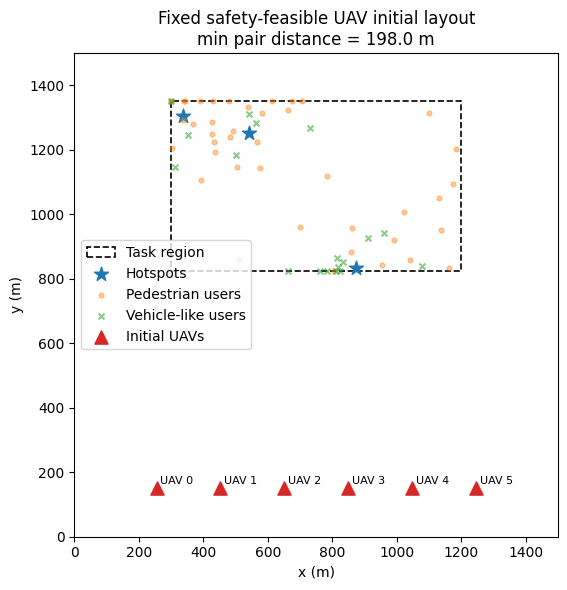

In [ ]:
# ============================================================
# Optional fixed-layout and trajectory visualization
# ============================================================

def pairwise_min_distance(points: np.ndarray) -> float:
    points = np.asarray(points, dtype=np.float32)
    if len(points) < 2:
        return float("inf")
    vals = []
    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            vals.append(float(np.linalg.norm(points[i] - points[j])))
    return min(vals)


def plot_fixed_initial_layout(cfg: Config = BASE_CFG, seed: int = 0, save: bool = True):
    """Plot the fixed UAV starting layout and one randomized user/hotspot sample."""
    env = UAVCommEnv(cfg, seed=seed)
    env.reset(seed)

    plt.figure(figsize=(6, 6))
    # Draw task region and randomized hotspots.
    x0, x1, y0, y1 = env._task_region_bounds()
    plt.gca().add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, linestyle="--", linewidth=1.2, label="Task region"))
    if hasattr(env, "hotspot_centers"):
        plt.scatter(env.hotspot_centers[:, 0], env.hotspot_centers[:, 1], s=110, marker="*", label="Hotspots")
    ped = getattr(env, "user_mobility_type", np.zeros(env.U, dtype=np.int64)) == 0
    veh = ~ped
    plt.scatter(env.user_pos[ped, 0], env.user_pos[ped, 1], s=12, alpha=0.40, label="Pedestrian users")
    plt.scatter(env.user_pos[veh, 0], env.user_pos[veh, 1], s=18, alpha=0.55, marker="x", label="Vehicle-like users")
    plt.scatter(env.uav_pos[:, 0], env.uav_pos[:, 1], s=90, marker="^", label="Initial UAVs")

    for i, p in enumerate(env.uav_pos):
        plt.text(float(p[0]) + 12, float(p[1]) + 12, f"UAV {i}", fontsize=8)

    plt.xlim(0, cfg.area_size)
    plt.ylim(0, cfg.area_size)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(
        "Fixed safety-feasible UAV initial layout\n"
        f"min pair distance = {pairwise_min_distance(env.uav_pos):.1f} m"
    )
    plt.legend(loc="best")
    plt.tight_layout()

    if save:
        path = os.path.join(OUTPUT_DIR, f"fig_staging_initial_layout_{SAFE_RUN_TAG}.png")
        plt.savefig(path, dpi=300)
        print("Saved:", path)

    plt.show()


def rollout_trajectory(
    trainer: BaseTrainer,
    cfg: Config = BASE_CFG,
    seed: int = 10000,
    deterministic: bool = True,
) -> Dict[str, np.ndarray]:
    """Roll out one episode and return UAV trajectories and final users."""
    env = UAVCommEnv(cfg, seed=seed)
    obs = env.reset(seed)

    uav_traj = [env.uav_pos.copy()]
    user_traj = [env.user_pos.copy()]
    done = False

    while not done:
        action, _ = trainer.act(obs, env, deterministic=deterministic)
        obs, _, done, _ = env.step(action)
        uav_traj.append(env.uav_pos.copy())
        user_traj.append(env.user_pos.copy())

    return {
        "uav_traj": np.asarray(uav_traj, dtype=np.float32),
        "user_final": np.asarray(user_traj[-1], dtype=np.float32),
        "user_initial": np.asarray(user_traj[0], dtype=np.float32),
    }


def plot_policy_trajectory(
    trainer: BaseTrainer,
    algo_name: str,
    cfg: Config = BASE_CFG,
    seed: int = 10000,
    deterministic: bool = True,
    save: bool = True,
):
    """Plot one representative evaluation trajectory.

    For trained IPPO/MAPPO/GAT-MAPPO, call this after loading/training the
    corresponding trainer. For Static-Fixed and Random, make_trainer is enough.
    """
    out = rollout_trajectory(trainer, cfg=cfg, seed=seed, deterministic=deterministic)
    traj = out["uav_traj"]

    plt.figure(figsize=(6, 6))
    plt.scatter(out["user_initial"][:, 0], out["user_initial"][:, 1], s=10, alpha=0.25, label="Users at t=0")
    plt.scatter(out["user_final"][:, 0], out["user_final"][:, 1], s=10, alpha=0.35, label="Users at T")

    for i in range(cfg.num_uav):
        xy = traj[:, i, :]
        plt.plot(xy[:, 0], xy[:, 1], linewidth=1.5)
        plt.scatter(xy[0, 0], xy[0, 1], marker="^", s=70)
        plt.scatter(xy[-1, 0], xy[-1, 1], marker="o", s=45)
        plt.text(float(xy[0, 0]) + 10, float(xy[0, 1]) + 10, f"{i}", fontsize=8)

    plt.xlim(0, cfg.area_size)
    plt.ylim(0, cfg.area_size)
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.title(f"Representative UAV trajectories — {algo_name}")
    plt.legend(loc="best")
    plt.tight_layout()

    if save:
        safe_algo = re.sub(r"[^A-Za-z0-9_.-]+", "_", algo_name)
        path = os.path.join(OUTPUT_DIR, f"fig_trajectory_{safe_algo}_{SAFE_RUN_TAG}.png")
        plt.savefig(path, dpi=300)
        print("Saved:", path)

    plt.show()



def load_trained_trainer_from_checkpoint(
    algo_name: str,
    seed: int = 0,
    scale_name: str = "paper_main",
    cfg: Config = BASE_CFG,
) -> BaseTrainer:
    """Create a trainer and load the completed checkpoint for trajectory plots."""
    trainer = make_trainer(algo_name, cfg)
    ckpt_file = checkpoint_path(scale_name, algo_name, seed)
    payload = load_training_checkpoint(
        ckpt_file,
        cfg=cfg,
        scale_name=scale_name,
        algo_name=algo_name,
        seed=seed,
        total_episodes=cfg.train_episodes if is_learning_algorithm(algo_name) else cfg.baseline_episodes,
    )
    if payload is None:
        raise FileNotFoundError(
            f"No compatible checkpoint found for {scale_name}/{algo_name}/seed={seed}: {ckpt_file}"
        )
    load_trainer_state(trainer, payload.get("trainer"))
    return trainer


def plot_trained_policy_trajectory(
    algo_name: str,
    seed: int = 0,
    eval_episode_seed: Optional[int] = None,
    scale_name: str = "paper_main",
    cfg: Config = BASE_CFG,
    save: bool = True,
):
    """Convenience wrapper to plot a trained policy after final runs finish."""
    if eval_episode_seed is None:
        eval_episode_seed = 10_000 + seed * 100

    trainer = load_trained_trainer_from_checkpoint(
        algo_name=algo_name,
        seed=seed,
        scale_name=scale_name,
        cfg=cfg,
    )
    plot_policy_trajectory(
        trainer,
        algo_name=f"{algo_name} seed={seed}",
        cfg=cfg,
        seed=eval_episode_seed,
        deterministic=(algo_name != "Random"),
        save=save,
    )

# Always safe to run before training:
plot_fixed_initial_layout(BASE_CFG, seed=0, save=True)

# Example for baselines before training:
# plot_policy_trajectory(make_trainer("Static-Fixed", BASE_CFG), "Static-Fixed", BASE_CFG, seed=10000)
# plot_policy_trajectory(make_trainer("Random", BASE_CFG), "Random", BASE_CFG, seed=10000, deterministic=False)

# After final training completes, examples:
# plot_trained_policy_trajectory("IPPO", seed=0)
# plot_trained_policy_trajectory("MAPPO", seed=0)
# plot_trained_policy_trajectory("GAT-MAPPO", seed=0)


## Execute assigned smoke/final workload

In [ ]:
# ============================================================
# Execute Assigned Workload
# ============================================================
# This FINAL_READY notebook runs the full final workload directly.
# Smoke/pilot testing is disabled by default in the previous cell.

EXPECTED_FINAL_ALGORITHMS = [
    "Static-Fixed",
    "Random",
    "Greedy-Demand-Safe",
    "IPPO",
    "MAPPO",
    "GAT-MAPPO",
]

assert "commsafety_shield_b128" in CHECKPOINT_RUN_TAG, CHECKPOINT_RUN_TAG
assert ALGORITHMS_TO_RUN == EXPECTED_FINAL_ALGORITHMS, ALGORITHMS_TO_RUN
assert "MADDPG" not in ALGORITHMS_TO_RUN
assert BASE_CFG.num_uav == 6 and BASE_CFG.num_users == 60
assert BASE_CFG.uav_init_mode == "fixed_staging"
assert BASE_CFG.use_paper_reward is True
assert BASE_CFG.max_uav_neighbors == 3
assert BASE_CFG.max_user_neighbors == 3
assert BASE_CFG.local_comm_feature_dim == 5
assert abs(BASE_CFG.separation_risk_weight - 5.0) < 1e-9
assert abs(BASE_CFG.lyapunov_kappa - 0.5) < 1e-9
assert abs(BASE_CFG.coverage_reward_weight - 2.0) < 1e-9
assert BASE_CFG.enable_safety_projection is True
assert BASE_CFG.train_episodes == 1500
assert BASE_CFG.ppo_minibatch_size == 128

print("=" * 80)
print("[EXECUTE ASSIGNED WORKLOAD]")
print("Preset:", EXPERIMENT_PRESET)
print("Run tag:", CHECKPOINT_RUN_TAG)
print("Resume:", RESUME_FROM_CACHE, "Strict:", STRICT_RESUME_CHECK)
print("Seeds:", RUN_SEEDS)
print("Algorithms:", ALGORITHMS_TO_RUN)
print("Training episodes for DRL/MARL:", BASE_CFG.train_episodes)
print("PPO minibatch size:", BASE_CFG.ppo_minibatch_size)
print("Baseline episodes:", BASE_CFG.baseline_episodes)
print("Evaluation episodes:", BASE_CFG.eval_episodes)
print("Checkpoint every episodes:", SAVE_EVERY_EPISODES)
print("Safety projection:", BASE_CFG.enable_safety_projection, "min_factor=", BASE_CFG.safety_projection_min_dist_factor, "iters=", BASE_CFG.safety_projection_iterations)
print("Best checkpoint min episode:", BASE_CFG.best_checkpoint_min_episode)
print("Learning runs:", 3 * len(RUN_SEEDS))
print("Non-learning/heuristic runs:", 3 * len(RUN_SEEDS))
print("Results JSON:", RESULTS_JSON)
print("=" * 80)

bm = BenchmarkManagerV2(BASE_CFG, RESULTS_JSON)
bm.run_grid(RUN_SCALES, ALGORITHMS_TO_RUN, RUN_SEEDS)

print("=" * 80)
print("[WORKLOAD COMPLETE]")
print("Results written to:", RESULTS_JSON)
print("=" * 80)


[EXECUTE ASSIGNED WORKLOAD]
Preset: paper_final_stagingmobility_commsafety_shield_b128_final
Run tag: paper_final_stagingmobility_commsafety_shield_b128_v1
Resume: True Strict: True
Seeds: [0, 1, 2, 3]
Algorithms: ['Static-Fixed', 'Random', 'Greedy-Demand-Safe', 'IPPO', 'MAPPO', 'GAT-MAPPO']
Training episodes for DRL/MARL: 1500
PPO minibatch size: 128
Baseline episodes: 50
Evaluation episodes: 10
Checkpoint every episodes: 10
Safety projection: True min_factor= 1.1 iters= 8
Best checkpoint min episode: 50
Learning runs: 12
Non-learning/heuristic runs: 12
Results JSON: /content/drive/MyDrive/6g_uav/outputs/main_benchmark_paper_final_stagingmobility_commsafety_shield_b128_v1.json
[SKIP] cached complete | scale=paper_main | algo=Static-Fixed | seed=0
[SKIP] cached complete | scale=paper_main | algo=Static-Fixed | seed=1
[SKIP] cached complete | scale=paper_main | algo=Static-Fixed | seed=2
[SKIP] cached complete | scale=paper_main | algo=Static-Fixed | seed=3
[SKIP] cached complete | scal

## Cell 12 — Statistical Aggregation: Mean ± 95% CI Across Seeds

In [ ]:
# ============================================================
# Cell 12 — Statistical Aggregation
# ============================================================

def collect_eval_dataframe(results_path: str = RESULTS_JSON) -> pd.DataFrame:
    results = load_json(results_path)
    rows = []
    for scale_name, algos in results.get("runs", {}).items():
        for algo_name, seeds in algos.items():
            for seed_str, payload in seeds.items():
                seed = int(seed_str)
                raw = payload.get("eval_raw", {})
                n = len(next(iter(raw.values()))) if raw else 0
                for i in range(n):
                    row = {"scale": scale_name, "algorithm": algo_name, "seed": seed, "eval_episode": i}
                    for k, vals in raw.items():
                        row[k] = vals[i]
                    rows.append(row)
    return pd.DataFrame(rows)




def collect_train_tail_dataframe(results_path: str = RESULTS_JSON) -> pd.DataFrame:
    """Collect last-20%-training summaries saved per run.

    This table is useful for convergence/stability discussion. It is not a
    replacement for deterministic final evaluation.
    """
    results = load_json(results_path)
    rows = []
    for scale_name, algos in results.get("runs", {}).items():
        for algo_name, seeds in algos.items():
            for seed_str, payload in seeds.items():
                tail = payload.get("train_tail_summary", {})
                meta = tail.get("_meta", {}) if isinstance(tail, dict) else {}
                row = {
                    "scale": scale_name,
                    "algorithm": algo_name,
                    "seed": int(seed_str),
                    "n_total_episodes": int(meta.get("n_total_episodes", 0)),
                    "n_tail_episodes": int(meta.get("n_tail_episodes", 0)),
                    "tail_start_episode": int(meta.get("start_episode", 0)),
                    "tail_end_episode": int(meta.get("end_episode", 0)),
                }
                if isinstance(tail, dict):
                    for metric, summary in tail.items():
                        if metric == "_meta" or not isinstance(summary, dict):
                            continue
                        for stat in ["mean", "std", "ci95", "n"]:
                            if stat in summary:
                                row[f"{metric}_{stat}"] = summary[stat]
                rows.append(row)
    return pd.DataFrame(rows)

def aggregate_seed_ci(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()

    # First aggregate eval episodes within each seed, then compute Student-t CI across seeds.
    metric_cols = [c for c in df.columns if c.startswith("ep_") and c not in {"eval_episode"}]
    seed_df = df.groupby(["scale", "algorithm", "seed"], as_index=False)[metric_cols].mean()

    rows = []
    for (scale, algo), g in seed_df.groupby(["scale", "algorithm"]):
        row = {"scale": scale, "algorithm": algo, "n_seeds": int(g["seed"].nunique())}
        for m in metric_cols:
            arr = g[m].to_numpy(dtype=np.float64)
            row[f"{m}_mean"] = float(np.mean(arr))
            row[f"{m}_std_seed"] = float(np.std(arr, ddof=1)) if len(arr) > 1 else 0.0
            row[f"{m}_ci95"] = ci95_t(arr)
        rows.append(row)

    return pd.DataFrame(rows)



def holm_adjust(p_values: List[float]) -> List[float]:
    """Holm step-down adjustment for a family of pairwise p-values.

    The returned p-values preserve the original input order and are monotone
    after sorting, which is the standard Holm correction used in the paper.
    """
    if not p_values:
        return []

    p = np.asarray(p_values, dtype=np.float64)
    m = len(p)
    order = np.argsort(p)
    adjusted = np.empty(m, dtype=np.float64)
    running_max = 0.0

    for rank, idx in enumerate(order):
        adj = (m - rank) * p[idx]
        running_max = max(running_max, float(adj))
        adjusted[idx] = min(running_max, 1.0)

    return adjusted.tolist()


def seed_level_metric_dataframe(df_eval: pd.DataFrame, metric: str) -> pd.DataFrame:
    """Average evaluation episodes within each seed before statistical testing."""
    if df_eval.empty or metric not in df_eval.columns:
        return pd.DataFrame(columns=["scale", "algorithm", "seed", metric])
    return df_eval.groupby(["scale", "algorithm", "seed"], as_index=False)[metric].mean()


def mannwhitney_against_proposed(
    df_eval: pd.DataFrame,
    metric: str = "ep_reward_mean",
    proposed: str = "GAT-MAPPO",
) -> pd.DataFrame:
    """Pairwise Mann--Whitney U tests against the proposed GAT-MAPPO.

    Testing unit: seed-level mean, not individual evaluation episode.
    Multiple comparisons within each scale/metric family are corrected with Holm.
    """
    seed_df = seed_level_metric_dataframe(df_eval, metric)
    if seed_df.empty:
        return pd.DataFrame()

    rows = []
    for scale, g in seed_df.groupby("scale"):
        prop_vals = g[g["algorithm"] == proposed][metric].to_numpy(dtype=np.float64)
        if len(prop_vals) == 0:
            continue

        tmp_rows = []
        pvals = []
        for algo in sorted(g["algorithm"].unique()):
            if algo == proposed:
                continue
            vals = g[g["algorithm"] == algo][metric].to_numpy(dtype=np.float64)
            if len(vals) == 0:
                continue

            stat, p = stats.mannwhitneyu(prop_vals, vals, alternative="two-sided", method="auto")
            prop_mean = float(np.mean(prop_vals))
            base_mean = float(np.mean(vals))
            tmp_rows.append({
                "scale": scale,
                "metric": metric,
                "proposed": proposed,
                "baseline": algo,
                "n_proposed": int(len(prop_vals)),
                "n_baseline": int(len(vals)),
                "proposed_mean": prop_mean,
                "baseline_mean": base_mean,
                "delta_proposed_minus_baseline": float(prop_mean - base_mean),
                "u_stat": float(stat),
                "p_raw": float(p),
            })
            pvals.append(float(p))

        if tmp_rows:
            p_holm = holm_adjust(pvals)
            for row, pa in zip(tmp_rows, p_holm):
                row["p_holm"] = float(pa)
                row["significant_0.05"] = bool(pa < 0.05)
                rows.append(row)

    return pd.DataFrame(rows)


def mannwhitney_suite_against_proposed(
    df_eval: pd.DataFrame,
    metrics: Optional[List[str]] = None,
    proposed: str = "GAT-MAPPO",
) -> pd.DataFrame:
    """Run Mann--Whitney/Holm tests for the paper's main reported metrics."""
    if metrics is None:
        metrics = [
            "ep_reward_mean",
            "ep_tput_mbps",
            "ep_qos",
            "ep_coverage",
            "ep_fairness",
            "ep_collisions",
        ]
    frames = [mannwhitney_against_proposed(df_eval, metric=m, proposed=proposed) for m in metrics]
    frames = [f for f in frames if not f.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


df_eval = collect_eval_dataframe(RESULTS_JSON)
summary_df = aggregate_seed_ci(df_eval)
train_tail_df = collect_train_tail_dataframe(RESULTS_JSON)
significance_df = mannwhitney_suite_against_proposed(df_eval, proposed="GAT-MAPPO")

print("Evaluation raw rows:", len(df_eval))
if not summary_df.empty:
    print("Final deterministic evaluation summary:")
    display(summary_df)
else:
    print("No evaluation results yet. Run benchmark cells first.")

if not significance_df.empty:
    print("Mann--Whitney U tests vs GAT-MAPPO with Holm correction:")
    display(significance_df)
else:
    print("No significance table yet. Need final evaluation results from at least one baseline and GAT-MAPPO.")

if not train_tail_df.empty:
    print("Last-20% training summary, for convergence/stability discussion:")
    display(train_tail_df)
else:
    print("No train-tail summary yet.")


Evaluation raw rows: 240
Final deterministic evaluation summary:


,scale,algorithm,n_seeds,ep_tput_mbps_mean,ep_tput_mbps_std_seed,ep_tput_mbps_ci95,ep_mean_rate_mbps_mean,ep_mean_rate_mbps_std_seed,ep_mean_rate_mbps_ci95,ep_throughput_score_mean,...,ep_adj_std_ci95,ep_adj_min_mean,ep_adj_min_std_seed,ep_adj_min_ci95,ep_adj_max_mean,ep_adj_max_std_seed,ep_adj_max_ci95,ep_adj_edge_density_mean,ep_adj_edge_density_std_seed,ep_adj_edge_density_ci95
0,paper_main,GAT-MAPPO,4,399.831967,10.138730,16.132982,6.663866,0.168979,0.268883,0.801603,...,0.012779,0.0,0.0,0.0,0.674313,0.059301,0.094361,0.449325,0.069149,0.110032
1,paper_main,Greedy-Demand-Safe,4,442.043746,4.422563,7.037285,7.367396,0.073709,0.117288,0.808827,...,0.007212,0.0,0.0,0.0,0.766993,0.010333,0.016441,0.434642,0.010765,0.017129
2,paper_main,IPPO,4,160.847913,63.497177,101.038179,2.680799,1.058286,1.683970,0.585728,...,0.068945,0.0,0.0,0.0,0.780789,0.072353,0.115129,0.291375,0.121448,0.193251
3,paper_main,MAPPO,4,280.298557,40.240440,64.031519,4.671643,0.670674,1.067192,0.760932,...,0.064248,0.0,0.0,0.0,0.792633,0.120036,0.191004,0.293900,0.054195,0.086237
4,paper_main,Random,4,48.146494,4.319198,6.872808,0.802442,0.071987,0.114547,0.282965,...,0.007379,0.0,0.0,0.0,0.847353,0.018502,0.029441,0.452283,0.011724,0.018656
5,paper_main,Static-Fixed,4,53.357446,5.765630,9.174404,0.889291,0.096094,0.152907,0.292905,...,0.000000,0.0,0.0,0.0,0.609571,0.000000,0.000000,0.533333,0.000000,0.000000


Mann--Whitney U tests vs GAT-MAPPO with Holm correction:


,scale,metric,proposed,baseline,n_proposed,n_baseline,proposed_mean,baseline_mean,delta_proposed_minus_baseline,u_stat,p_raw,p_holm,significant_0.05
0,paper_main,ep_reward_mean,GAT-MAPPO,Greedy-Demand-Safe,4,4,44.190354,49.457438,-5.267084,0.0,0.028571,0.142857,False
1,paper_main,ep_reward_mean,GAT-MAPPO,IPPO,4,4,44.190354,17.223575,26.966778,16.0,0.028571,0.142857,False
2,paper_main,ep_reward_mean,GAT-MAPPO,MAPPO,4,4,44.190354,30.981877,13.208477,16.0,0.028571,0.142857,False
3,paper_main,ep_reward_mean,GAT-MAPPO,Random,4,4,44.190354,4.495688,39.694666,16.0,0.028571,0.142857,False
4,paper_main,ep_reward_mean,GAT-MAPPO,Static-Fixed,4,4,44.190354,4.921908,39.268446,16.0,0.028571,0.142857,False
5,paper_main,ep_tput_mbps,GAT-MAPPO,Greedy-Demand-Safe,4,4,399.831967,442.043746,-42.211778,0.0,0.028571,0.142857,False
6,paper_main,ep_tput_mbps,GAT-MAPPO,IPPO,4,4,399.831967,160.847913,238.984054,16.0,0.028571,0.142857,False
7,paper_main,ep_tput_mbps,GAT-MAPPO,MAPPO,4,4,399.831967,280.298557,119.533410,16.0,0.028571,0.142857,False
8,paper_main,ep_tput_mbps,GAT-MAPPO,Random,4,4,399.831967,48.146494,351.685473,16.0,0.028571,0.142857,False
9,paper_main,ep_tput_mbps,GAT-MAPPO,Static-Fixed,4,4,399.831967,53.357446,346.474521,16.0,0.028571,0.142857,False


Last-20% training summary, for convergence/stability discussion:


,scale,algorithm,seed,n_total_episodes,n_tail_episodes,tail_start_episode,tail_end_episode,ep_active_ratio_mean,ep_active_ratio_std,ep_active_ratio_ci95,...,ep_team_reward_ci95,ep_team_reward_n,ep_throughput_score_mean,ep_throughput_score_std,ep_throughput_score_ci95,ep_throughput_score_n,ep_tput_mbps_mean,ep_tput_mbps_std,ep_tput_mbps_ci95,ep_tput_mbps_n
0,paper_main,Static-Fixed,0,50,10,41,50,1.0,0.0,0.0,...,3.360437,10,0.303935,0.165429,0.118341,10,63.842111,45.871761,32.814681,10
1,paper_main,Static-Fixed,1,50,10,41,50,1.0,0.0,0.0,...,2.684965,10,0.247915,0.146926,0.105105,10,47.479074,36.603630,26.184659,10
2,paper_main,Static-Fixed,2,50,10,41,50,1.0,0.0,0.0,...,2.188860,10,0.278158,0.135744,0.097105,10,50.213241,29.556803,21.143663,10
3,paper_main,Static-Fixed,3,50,10,41,50,1.0,0.0,0.0,...,2.872360,10,0.310252,0.165855,0.118645,10,58.856708,39.096124,27.967682,10
4,paper_main,Random,0,50,10,41,50,1.0,0.0,0.0,...,1.916960,10,0.226184,0.113275,0.081032,10,39.296947,26.085034,18.660109,10
5,paper_main,Random,1,50,10,41,50,1.0,0.0,0.0,...,2.470849,10,0.259280,0.141246,0.101042,10,45.423324,33.530732,23.986440,10
6,paper_main,Random,2,50,10,41,50,1.0,0.0,0.0,...,2.150293,10,0.259406,0.146350,0.104692,10,44.303315,29.214235,20.898605,10
7,paper_main,Random,3,50,10,41,50,1.0,0.0,0.0,...,2.783505,10,0.295822,0.168038,0.120207,10,52.937397,37.841497,27.070176,10
8,paper_main,Greedy-Demand-Safe,0,50,10,41,50,1.0,0.0,0.0,...,2.043746,10,0.813784,0.024702,0.017671,10,459.591693,24.624212,17.615100,10
9,paper_main,Greedy-Demand-Safe,1,50,10,41,50,1.0,0.0,0.0,...,2.636298,10,0.816331,0.045738,0.032719,10,451.543773,33.657157,24.076879,10


## Cell 13 — IEEE-Style Visualization and Export

Generates:

1. Training convergence curves with 95% CI shading.
2. QoS and fairness boxplots.
3. Safety-throughput Pareto scatter plot.

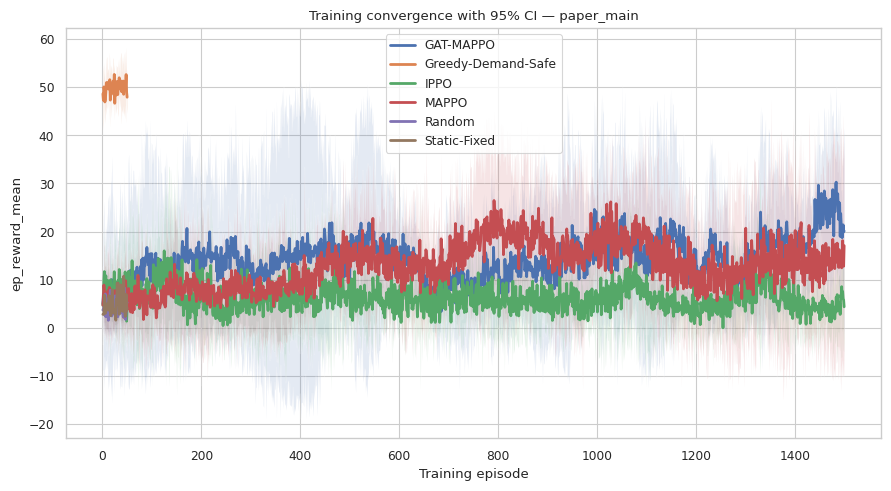

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_convergence_paper_main_ep_reward_mean.png


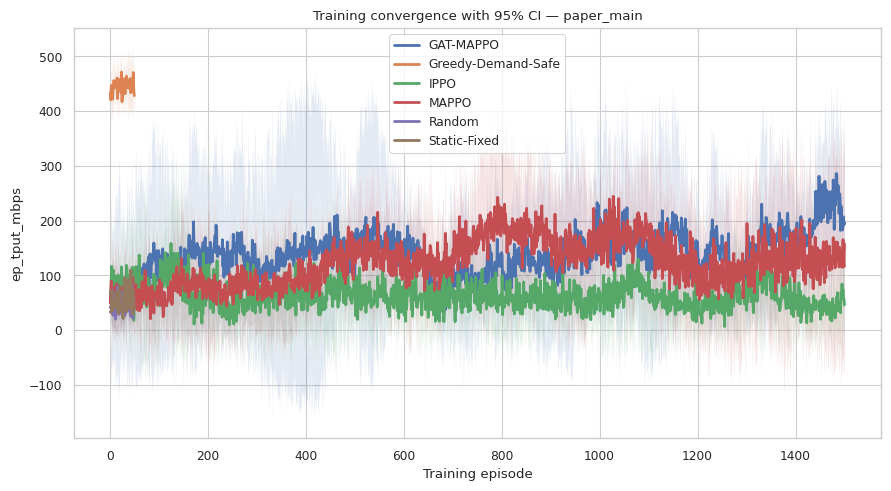

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_convergence_paper_main_ep_tput_mbps.png


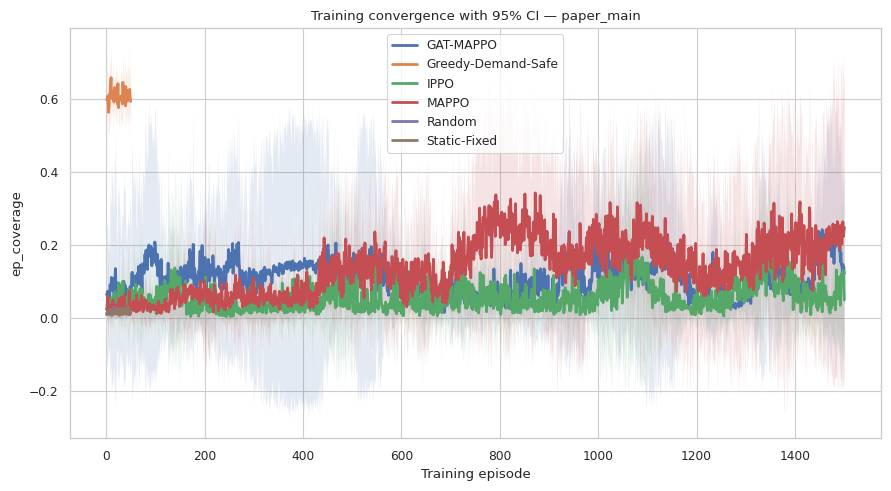

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_convergence_paper_main_ep_coverage.png


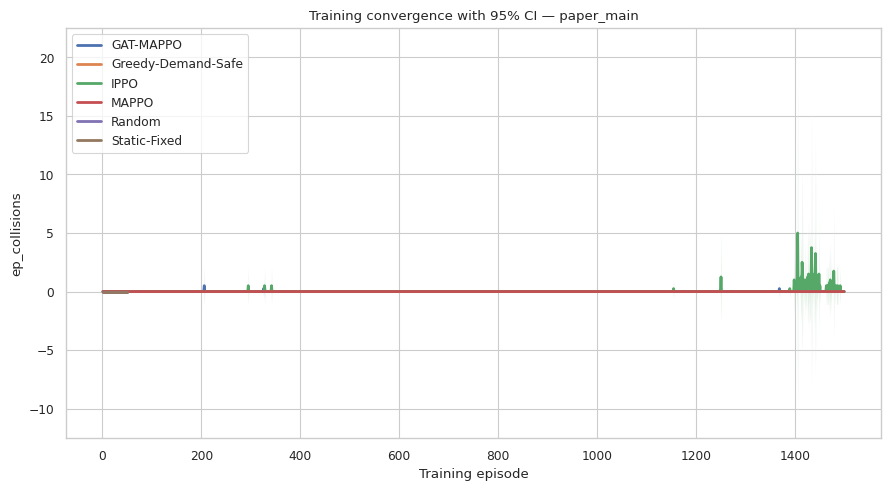

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_convergence_paper_main_ep_collisions.png


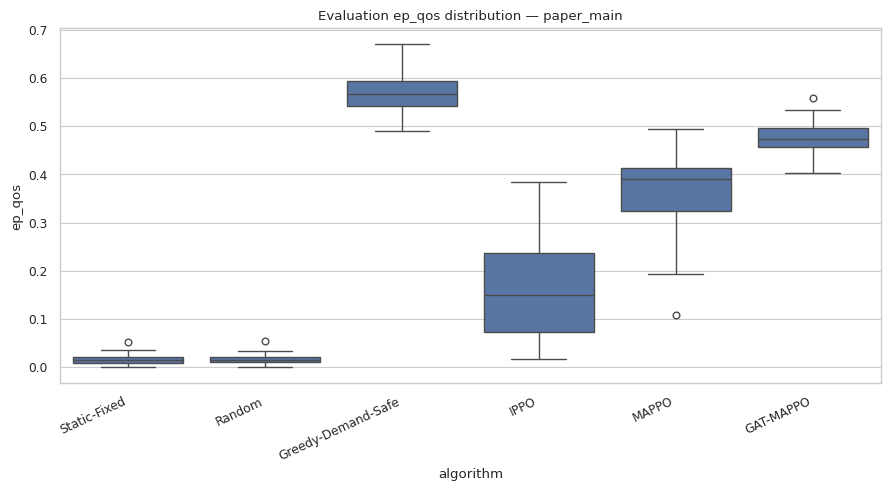

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_boxplot_paper_main_ep_qos.png


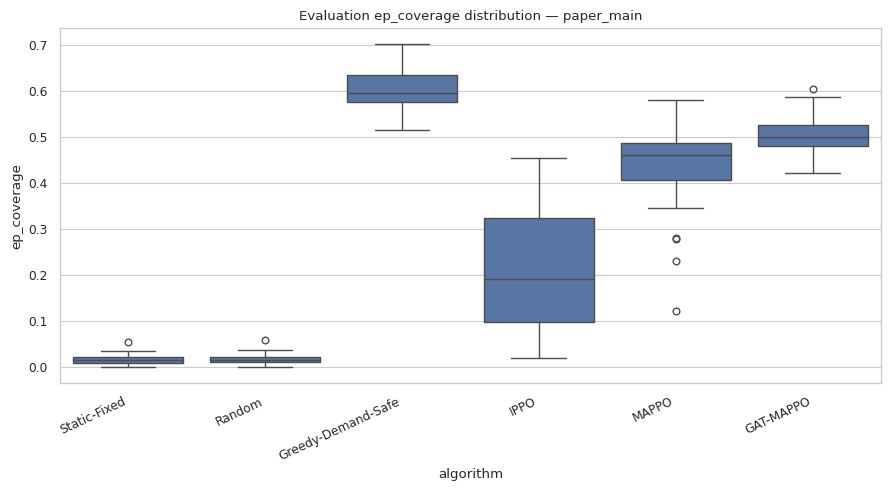

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_boxplot_paper_main_ep_coverage.png


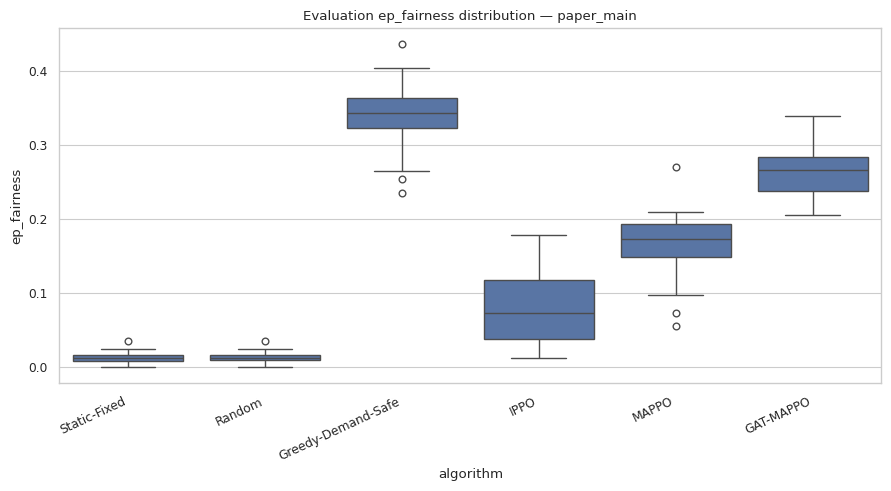

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_boxplot_paper_main_ep_fairness.png


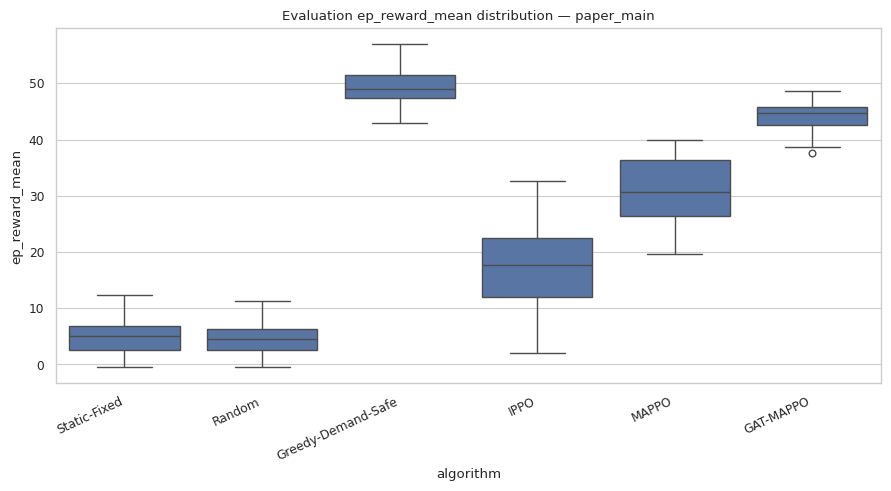

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_boxplot_paper_main_ep_reward_mean.png


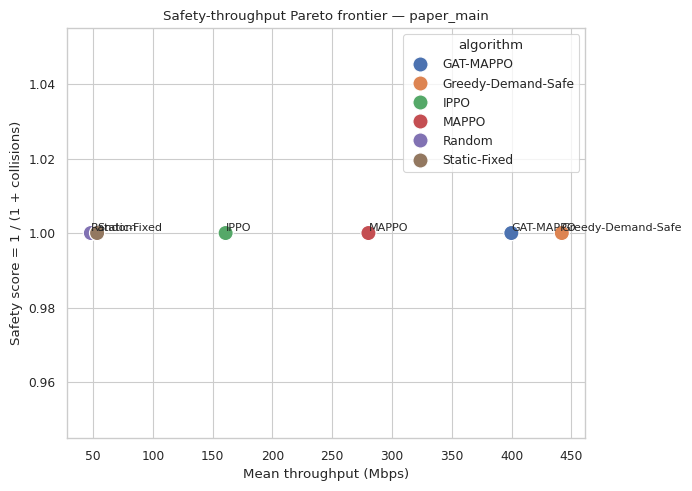

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_pareto_paper_main.png


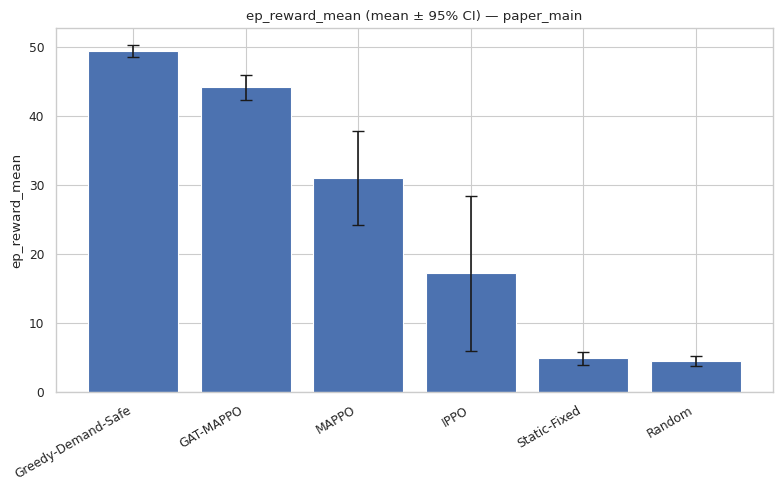

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_eval_ci_paper_main_ep_reward_mean.png


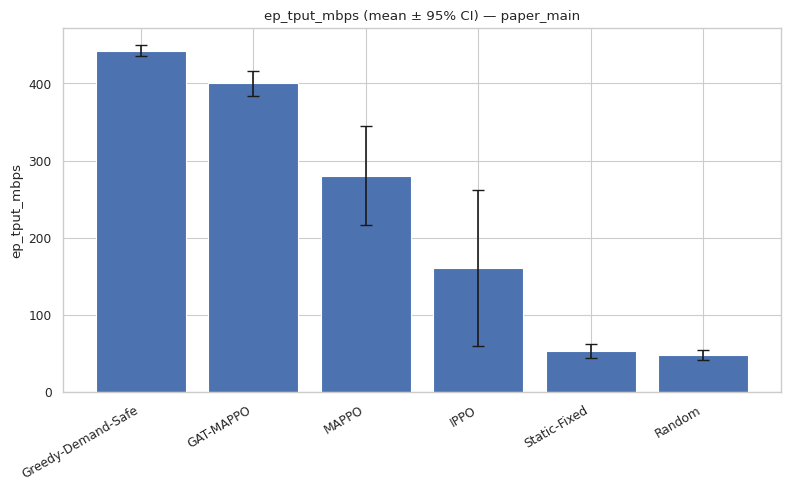

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_eval_ci_paper_main_ep_tput_mbps.png


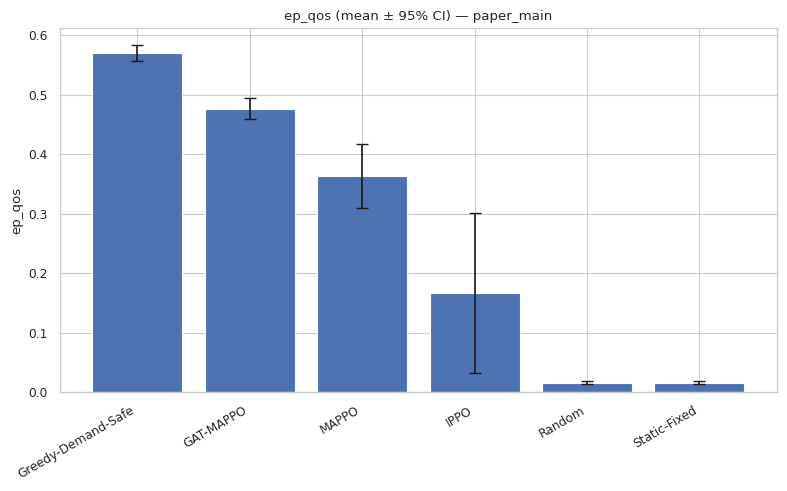

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_eval_ci_paper_main_ep_qos.png


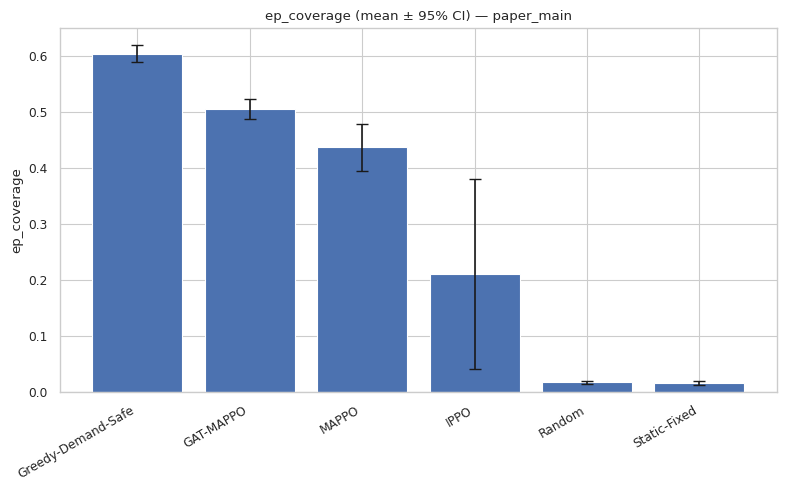

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_eval_ci_paper_main_ep_coverage.png


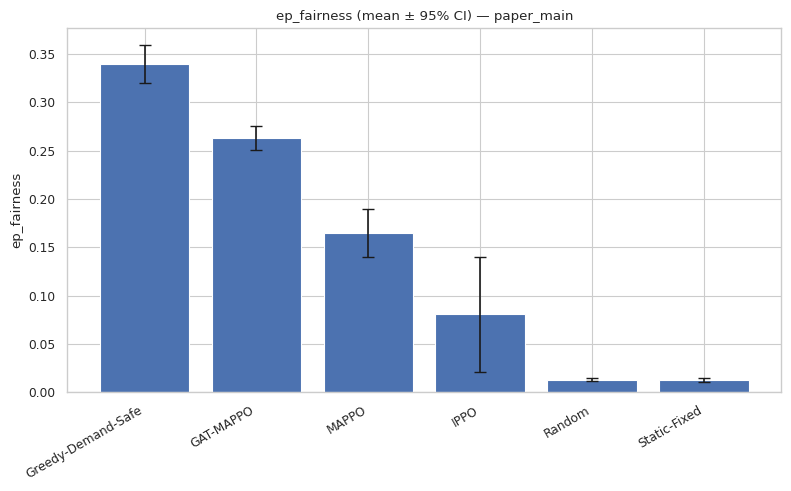

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_eval_ci_paper_main_ep_fairness.png


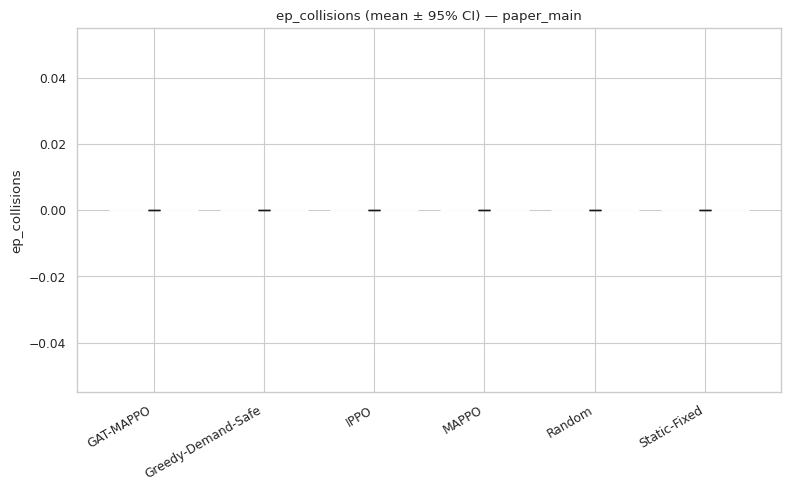

Saved: /content/drive/MyDrive/6g_uav/outputs/fig_eval_ci_paper_main_ep_collisions.png
Structured raw results exported to: /content/drive/MyDrive/6g_uav/outputs/main_benchmark_paper_final_stagingmobility_commsafety_shield_b128_v1.json
Saved: /content/drive/MyDrive/6g_uav/outputs/eval_summary_paper_final_stagingmobility_commsafety_shield_b128_v1.csv
Saved: /content/drive/MyDrive/6g_uav/outputs/train_history_paper_final_stagingmobility_commsafety_shield_b128_v1.csv
Saved: /content/drive/MyDrive/6g_uav/outputs/train_tail_summary_paper_final_stagingmobility_commsafety_shield_b128_v1.csv
Saved: /content/drive/MyDrive/6g_uav/outputs/mannwhitney_holm_paper_final_stagingmobility_commsafety_shield_b128_v1.csv


In [ ]:
# ============================================================
# IEEE-Style Plotting and Export
# ============================================================

sns.set_theme(style="whitegrid", context="paper")


def moving_average(x: np.ndarray, w: int = 10) -> np.ndarray:
    if len(x) < w:
        return x
    return np.convolve(x, np.ones(w) / w, mode="valid")


def collect_training_dataframe(results_path: str = RESULTS_JSON) -> pd.DataFrame:
    results = load_json(results_path)
    rows = []
    for scale_name, algos in results.get("runs", {}).items():
        for algo_name, seeds in algos.items():
            for seed_str, payload in seeds.items():
                for ep, item in enumerate(payload.get("train_history", []), start=1):
                    rows.append({"scale": scale_name, "algorithm": algo_name, "seed": int(seed_str), "episode": ep, **item})
    return pd.DataFrame(rows)


def plot_convergence(df_train: pd.DataFrame, scale: str, metric: str = "ep_tput_mbps"):
    sub = df_train[df_train["scale"] == scale].copy()
    if sub.empty or metric not in sub.columns:
        print(f"No training data available for convergence plot: scale={scale}, metric={metric}")
        return

    plt.figure(figsize=(9, 5))
    for algo, g in sub.groupby("algorithm"):
        pivot = g.pivot_table(index="episode", columns="seed", values=metric, aggfunc="mean").sort_index()
        mean = pivot.mean(axis=1).to_numpy()
        std = pivot.std(axis=1).fillna(0.0).to_numpy()
        n = max(1, pivot.shape[1])
        if n > 1:
            tcrit = float(stats.t.ppf(0.975, df=n - 1))
            ci = tcrit * std / math.sqrt(n)
        else:
            ci = np.zeros_like(std)
        x = pivot.index.to_numpy()
        plt.plot(x, mean, label=algo, linewidth=2)
        plt.fill_between(x, mean - ci, mean + ci, alpha=0.15)
    plt.xlabel("Training episode")
    plt.ylabel(metric)
    plt.title(f"Training convergence with 95% CI — {scale}")
    plt.legend()
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"fig_convergence_{scale}_{metric}.png")
    plt.savefig(path, dpi=300)
    plt.show()
    print("Saved:", path)


def plot_boxplots(df_eval: pd.DataFrame, scale: str):
    sub = df_eval[df_eval["scale"] == scale].copy()
    if sub.empty:
        print(f"No evaluation data available for boxplots: {scale}")
        return
    for metric in ["ep_qos", "ep_coverage", "ep_fairness", "ep_reward_mean"]:
        if metric not in sub.columns:
            continue
        plt.figure(figsize=(9, 5))
        sns.boxplot(data=sub, x="algorithm", y=metric)
        plt.xticks(rotation=25, ha="right")
        plt.title(f"Evaluation {metric} distribution — {scale}")
        plt.tight_layout()
        path = os.path.join(OUTPUT_DIR, f"fig_boxplot_{scale}_{metric}.png")
        plt.savefig(path, dpi=300)
        plt.show()
        print("Saved:", path)


def plot_pareto(df_eval: pd.DataFrame, scale: str):
    sub = df_eval[df_eval["scale"] == scale].copy()
    if sub.empty:
        print(f"No evaluation data available for Pareto plot: {scale}")
        return
    agg = sub.groupby("algorithm", as_index=False).agg(
        throughput=("ep_tput_mbps", "mean"),
        collisions=("ep_collisions", "mean"),
        qos=("ep_qos", "mean"),
        coverage=("ep_coverage", "mean"),
        fairness=("ep_fairness", "mean"),
    )
    agg["safety_score"] = 1.0 / (1.0 + agg["collisions"])
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=agg, x="throughput", y="safety_score", hue="algorithm", s=120)
    for _, r in agg.iterrows():
        plt.text(r["throughput"], r["safety_score"], r["algorithm"], fontsize=8, ha="left", va="bottom")
    plt.xlabel("Mean throughput (Mbps)")
    plt.ylabel("Safety score = 1 / (1 + collisions)")
    plt.title(f"Safety-throughput Pareto frontier — {scale}")
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"fig_pareto_{scale}.png")
    plt.savefig(path, dpi=300)
    plt.show()
    print("Saved:", path)


def plot_eval_ci_bars(summary_df: pd.DataFrame, scale: str, metric: str):
    sub = summary_df[summary_df["scale"] == scale].copy()
    if sub.empty:
        print(f"No evaluation summary available for CI bar plot: {scale}")
        return

    mean_col = f"{metric}_mean"
    ci_col = f"{metric}_ci95"
    if mean_col not in sub.columns or ci_col not in sub.columns:
        print(f"Missing columns for metric={metric}")
        return

    sub = sub.sort_values(mean_col, ascending=False)

    plt.figure(figsize=(8, 5))
    plt.bar(sub["algorithm"], sub[mean_col], yerr=sub[ci_col], capsize=4)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} (mean ± 95% CI) — {scale}")
    plt.tight_layout()

    path = os.path.join(OUTPUT_DIR, f"fig_eval_ci_{scale}_{metric}.png")
    plt.savefig(path, dpi=300)
    plt.show()
    print("Saved:", path)


df_train = collect_training_dataframe(RESULTS_JSON)
df_eval = collect_eval_dataframe(RESULTS_JSON)
summary_df = aggregate_seed_ci(df_eval)
train_tail_df = collect_train_tail_dataframe(RESULTS_JSON)
significance_df = mannwhitney_suite_against_proposed(df_eval, proposed="GAT-MAPPO")

for scale in sorted(set(df_train["scale"].unique()) if not df_train.empty else []):
    for metric in ["ep_reward_mean", "ep_tput_mbps", "ep_coverage", "ep_collisions"]:
        plot_convergence(df_train, scale=scale, metric=metric)

for scale in sorted(set(df_eval["scale"].unique()) if not df_eval.empty else []):
    plot_boxplots(df_eval, scale=scale)
    plot_pareto(df_eval, scale=scale)
    for metric in ["ep_reward_mean", "ep_tput_mbps", "ep_qos", "ep_coverage", "ep_fairness", "ep_collisions"]:
        plot_eval_ci_bars(summary_df, scale=scale, metric=metric)

summary_csv = os.path.join(OUTPUT_DIR, f"eval_summary_{SAFE_RUN_TAG}.csv")
train_csv = os.path.join(OUTPUT_DIR, f"train_history_{SAFE_RUN_TAG}.csv")
train_tail_csv = os.path.join(OUTPUT_DIR, f"train_tail_summary_{SAFE_RUN_TAG}.csv")
significance_csv = os.path.join(OUTPUT_DIR, f"mannwhitney_holm_{SAFE_RUN_TAG}.csv")
summary_df.to_csv(summary_csv, index=False)
df_train.to_csv(train_csv, index=False)
train_tail_df.to_csv(train_tail_csv, index=False)
significance_df.to_csv(significance_csv, index=False)

print("Structured raw results exported to:", RESULTS_JSON)
print("Saved:", summary_csv)
print("Saved:", train_csv)
print("Saved:", train_tail_csv)
print("Saved:", significance_csv)
